# EVALUACIÓN EA3: TRANSFORMERS PARA NLP - DAILYDIALOG

# Introducción y Objetivos
# Evaluación EA3: Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)

**Dataset**: DailyDialog  
**Objetivo**: Implementar un modelo Transformer encoder-decoder para generación de respuestas en diálogos cotidianos

## Criterios de Evaluación:
- **Implementación correcta del modelo Transformer** (30%)
- **Preprocesamiento adecuado de datos** (20%)
- **Entrenamiento y optimización** (25%)
- **Evaluación con métricas apropiadas** (15%)
- **Análisis de resultados y conclusiones** (10%)

## Componentes clave a implementar:
1. Encoder-Decoder Transformer
2. Atención Multi-cabezal
3. Embeddings posicionales
4. Evaluación con BLEU/ROUGE
5. Ajuste de hiperparámetros

**Tiempo estimado**: 4-6 horas

In [ ]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau
import re
import string
import ast
from sklearn.model_selection import train_test_split
from collections import Counter
import ast
import re
import warnings
import time
warnings.filterwarnings('ignore')

# Configuración para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.18.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cargar y explorar datasets

Cargamos los datasets de train, test y validation, observación general de los datos y sus estructuras

In [ ]:
# Cargar los datasets
print("Cargando datasets...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
validation_df = pd.read_csv('validation.csv')

print(f"Dataset de entrenamiento: {train_df.shape}")
print(f"Dataset de prueba: {test_df.shape}")
print(f"Dataset de validación: {validation_df.shape}")

# Mostrar información básica
print("\n=== INFORMACIÓN BÁSICA ===")
print("Columnas disponibles:", train_df.columns.tolist())
print("\nPrimeras 3 filas del dataset de entrenamiento:")
print(train_df.head(3))

# Verificar tipos de datos
print("\n=== TIPOS DE DATOS ===")
print(train_df.dtypes)

# ANÁLISIS ADICIONAL DE LOS DATOS
print("\n=== ANÁLISIS DETALLADO DE LOS DATOS ===")

# Verificar valores nulos
print("Valores nulos por columna:")
print(f"- train: {train_df.isnull().sum().to_dict()}")
print(f"- test: {test_df.isnull().sum().to_dict()}")
print(f"- validation: {validation_df.isnull().sum().to_dict()}")

# Analizar la estructura de los diálogos
print("\n=== ESTRUCTURA DE DIÁLOGOS ===")
sample_dialog = train_df.iloc[0]['dialog']
print(f"Ejemplo de diálogo (raw): {repr(sample_dialog[:200])}...")
print(f"Tipo: {type(sample_dialog)}")

# Verificar patrones en los diálogos
dialog_patterns = {
    'starts_with_bracket': sum(1 for d in train_df['dialog'] if str(d).startswith('[')),
    'contains_newline': sum(1 for d in train_df['dialog'] if '\\n' in str(d)),
    'contains_quotes': sum(1 for d in train_df['dialog'] if '"' in str(d) or "'" in str(d))
}

print(f"Patrones en diálogos (total: {len(train_df)}):")
for pattern, count in dialog_patterns.items():
    print(f"- {pattern}: {count} ({count/len(train_df)*100:.1f}%)")

# Analizar las columnas 'act' y 'emotion'
print("\n=== ANÁLISIS DE METADATOS ===")
sample_act = train_df.iloc[0]['act']
sample_emotion = train_df.iloc[0]['emotion']

print(f"Ejemplo de 'act': {sample_act} (tipo: {type(sample_act)})")
print(f"Ejemplo de 'emotion': {sample_emotion} (tipo: {type(sample_emotion)})")

# Verificar longitudes de las secuencias de metadatos
try:
    # Intentar parsear algunos ejemplos de act y emotion
    sample_acts_parsed = []
    sample_emotions_parsed = []

    for i in range(min(5, len(train_df))):
        try:
            act_parsed = ast.literal_eval(train_df.iloc[i]['act'])
            emotion_parsed = ast.literal_eval(train_df.iloc[i]['emotion'])
            sample_acts_parsed.append(len(act_parsed))
            sample_emotions_parsed.append(len(emotion_parsed))
        except:
            sample_acts_parsed.append(0)
            sample_emotions_parsed.append(0)

    print(f"Longitudes de 'act' en primeros 5 ejemplos: {sample_acts_parsed}")
    print(f"Longitudes de 'emotion' en primeros 5 ejemplos: {sample_emotions_parsed}")

except Exception as e:
    print(f"Error parseando metadatos: {e}")

# Estadísticas generales
print(f"\n=== ESTADÍSTICAS GENERALES ===")
print(f"Total de diálogos disponibles: {len(train_df) + len(test_df) + len(validation_df):,}")
print(f"Distribución:")
print(f"- Entrenamiento: {len(train_df):,} ({len(train_df)/(len(train_df)+len(test_df)+len(validation_df))*100:.1f}%)")
print(f"- Prueba: {len(test_df):,} ({len(test_df)/(len(train_df)+len(test_df)+len(validation_df))*100:.1f}%)")
print(f"- Validación: {len(validation_df):,} ({len(validation_df)/(len(train_df)+len(test_df)+len(validation_df))*100:.1f}%)")

# Verificar consistencia entre datasets
print(f"\n=== VERIFICACIÓN DE CONSISTENCIA ===")
print("Columnas en cada dataset:")
print(f"- Train: {train_df.columns.tolist()}")
print(f"- Test: {test_df.columns.tolist()}")
print(f"- Validation: {validation_df.columns.tolist()}")

# Verificar si las columnas son consistentes
columns_consistent = (
    set(train_df.columns) == set(test_df.columns) == set(validation_df.columns)
)
print(f"Columnas consistentes entre datasets: {'✅' if columns_consistent else '❌'}")

print("\n" + "="*60)
print("✅ CARGA Y ANÁLISIS INICIAL COMPLETADO")
print("📋 Datos listos para preprocesamiento")
print("="*60)

Cargando datasets...
Dataset de entrenamiento: (11118, 3)
Dataset de prueba: (1000, 3)
Dataset de validación: (1000, 3)

=== INFORMACIÓN BÁSICA ===
Columnas disponibles: ['dialog', 'act', 'emotion']

Primeras 3 filas del dataset de entrenamiento:
                                              dialog                    act  \
0  ['Say , Jim , how about going for a few beers ...  [3 4 2 2 2 3 4 1 3 4]   
1  ['Can you do push-ups ? '\n " Of course I can ...          [2 1 2 2 1 1]   
2  ['Can you study with the radio on ? '\n ' No ,...            [2 1 2 1 1]   

                 emotion  
0  [0 0 0 0 0 0 4 4 4 4]  
1          [0 0 6 0 0 0]  
2            [0 0 0 0 0]  

=== TIPOS DE DATOS ===
dialog     object
act        object
emotion    object
dtype: object

=== ANÁLISIS DETALLADO DE LOS DATOS ===
Valores nulos por columna:
- train: {'dialog': 0, 'act': 0, 'emotion': 0}
- test: {'dialog': 0, 'act': 0, 'emotion': 0}
- validation: {'dialog': 0, 'act': 0, 'emotion': 0}

=== ESTRUCTURA DE DIÁL

## Análisis exploratorio de datos

In [ ]:
# Función para procesar diálogos (convertir string a lista)
def parse_dialog_robust(dialog_str):
    """Convierte string de diálogo a lista de frases de forma robusta"""
    if not isinstance(dialog_str, str):
        return []
    try:
        # Intentar con ast.literal_eval primero
        dialog_list = ast.literal_eval(dialog_str)
        if isinstance(dialog_list, list):
            # Limpiar cada elemento de la lista
            cleaned_list = [str(item).strip() for item in dialog_list if str(item).strip()]
            return cleaned_list
    except (SyntaxError, ValueError):
        pass # Fallback to manual parsing

    # Fallback: procesamiento manual basado en la estructura observada
    # Remover corchetes externos si existen
    content = dialog_str.strip()
    if content.startswith('[') and content.endswith(']'):
        content = content[1:-1]

    # Dividir por patrones que indican nuevos turnos, como '\n ' seguido de comilla
    turns = []

    # Dividir por saltos de línea seguidos de espacio y comilla
    # Using raw string for regex pattern
    parts = re.split(r'\n\s*[\'"]', content)

    for i, part in enumerate(parts):
        if i == 0:
            # Primera parte, remover comilla inicial si existe
            part = part.lstrip('\'"')

        # Limpiar la parte
        part = part.strip()

        # Remover comillas finales si existen
        if part.endswith('"') or part.endswith("'"):
            part = part[:-1]

        # Remover patrones como ' " o " ' del final/inicio
        part = re.sub(r'^[\'"\s]+|[\'"\s]+$', '', part.strip())

        if part and len(part.strip()) > 5: # Solo turnos con contenido significativo
            turns.append(part.strip())

    # Si no encontramos múltiples turnos, intentar otro método (e.g., splitting by quotes)
    if len(turns) <= 1:
         # Buscar patrones de comillas que encierran frases completas
        pattern = r'[\'"][^\'"\n]*[\'"]'
        matches = re.findall(pattern, content)

        if len(matches) > 1:
            turns = []
            for match in matches:
                clean_match = re.sub(r'^[\'"]|[\'"]$', '', match).strip()
                if len(clean_match) > 5:
                    turns.append(clean_match)

    # Filtrar y retornar solo si hay al menos 2 turnos válidos
    valid_turns = [turn for turn in turns if len(turn) > 5]

    return valid_turns if len(valid_turns) >= 2 else []


# ANÁLISIS MEJORADO DE ESTRUCTURA DE DIÁLOGOS
print("=== ANÁLISIS MEJORADO DE ESTRUCTURA DE DIÁLOGOS ===")

# Probar con múltiples ejemplos
for idx in range(3):
    print(f"\n--- DIÁLOGO {idx + 1} ---")
    sample_dialog = train_df.iloc[idx]['dialog']
    print("Diálogo original (primeros 200 chars):")
    print(repr(sample_dialog[:200]) + "...")

    # Usar el parser mejorado
    processed_dialog = parse_dialog_robust(sample_dialog)
    print(f"\nDiálogo procesado ({len(processed_dialog)} turnos):")

    if len(processed_dialog) >= 2:
        for i, turn in enumerate(processed_dialog[:5]): # Solo mostrar primeros 5 turnos
            print(f"Turno {i+1}: {turn[:80]}{'...' if len(turn) > 80 else ''}")
        if len(processed_dialog) > 5:
            print(f"... y {len(processed_dialog) - 5} turnos más")
    else:
        print("❌ No se pudieron separar los turnos correctamente o menos de 2 turnos válidos")
    print("-" * 60)


# Analizar longitudes con el parser mejorado
print("\n=== ANÁLISIS DE LONGITUDES CON PARSER MEJORADO ===")
dialog_lengths_improved = []
successful_parses = 0
failed_parses = 0

for idx, row in train_df.head(1000).iterrows(): # Analizar primeros 1000 para mejor muestra
    try:
        dialog = parse_dialog_robust(row['dialog'])
        dialog_lengths_improved.append(len(dialog))
        if len(dialog) >= 2:
            successful_parses += 1
        else:
            failed_parses += 1
    except:
        dialog_lengths_improved.append(0)
        failed_parses += 1

print(f"=== ESTADÍSTICAS DE PARSING ===")
print(f"Diálogos parseados exitosamente (>= 2 turnos): {successful_parses}")
print(f"Diálogos fallidos (< 2 turnos o error): {failed_parses}")
# Avoid division by zero if total is 0
total_analyzed = successful_parses + failed_parses
if total_analyzed > 0:
    print(f"Tasa de éxito (>= 2 turnos): {successful_parses/total_analyzed*100:.1f}%")
else:
    print("No dialogues analyzed.")


if successful_parses > 0:
    # Solo considerar diálogos exitosos para estadísticas
    successful_lengths = [l for l in dialog_lengths_improved if l >= 2]

    print(f"\n=== ESTADÍSTICAS DE LONGITUD (SOLO EXITOSOS) ===")
    print(f"Longitud promedio: {np.mean(successful_lengths):.2f} turnos")
    print(f"Longitud mínima: {np.min(successful_lengths)} turnos")
    print(f"Longitud máxima: {np.max(successful_lengths)} turnos")
    print(f"Mediana: {np.median(successful_lengths):.2f} turnos")

    # Visualización mejorada
    plt.figure(figsize=(15, 5))

    # Histograma de longitudes exitosas
    plt.subplot(1, 3, 1)
    plt.hist(successful_lengths, bins=20, alpha=0.7, edgecolor='black')
    plt.title('Distribución de Longitud de Diálogos\n(Parser Mejorado)')
    plt.xlabel('Número de turnos')
    plt.ylabel('Frecuencia')
    plt.axvline(np.mean(successful_lengths), color='red', linestyle='--',
               label=f'Promedio: {np.mean(successful_lengths):.1f}')
    plt.legend()

    # Box plot
    plt.subplot(1, 3, 2)
    plt.boxplot(successful_lengths)
    plt.title('Box Plot - Longitud de Diálogos')
    plt.ylabel('Número de turnos')
    plt.grid(True, alpha=0.3)

    # Comparación de tasas de éxito
    plt.subplot(1, 3, 3)
    labels = ['Exitosos (>= 2 turnos)', 'Fallidos (< 2 turnos o error)']
    sizes = [successful_parses, failed_parses]
    colors = ['lightgreen', 'lightcoral']
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Tasa de Éxito del Parser')

    plt.tight_layout()
    plt.show()

    # Recomendaciones para max_seq_length
    percentile_95 = np.percentile(successful_lengths, 95)
    print(f"\n=== RECOMENDACIONES ===")
    print(f"95% de diálogos tienen ≤ {percentile_95:.0f} turnos")
    print(f"Recomendación para max_seq_length en tokens:")
    # Adjusting assumptions based on typical sentence lengths
    print(f"- Conservador: ~{int(percentile_95 * 20)} tokens (asumiendo ~20 tokens/turno)")
    print(f"- Balanceado: ~{int(np.mean(successful_lengths) * 25)} tokens (asumiendo ~25 tokens/turno)")


else:
    print("❌ El parser mejorado no encontró suficientes diálogos con al menos 2 turnos.")
    print("Necesitamos analizar el formato específico más detalladamente.")

    # Análisis más profundo del formato (with corrected f-strings)
    print("\n=== ANÁLISIS PROFUNDO DEL FORMATO ===")
    # Taking a sample, ensuring it's a string
    sample = str(train_df.iloc[0]['dialog']) if not train_df.empty else ""
    if sample:
        print("Caracteres especiales encontrados:")
        special_chars = {}
        for char in sample:
            if not char.isalnum() and char not in ' .,!?\'"[]\\n': # Include expected special chars
                special_chars[char] = special_chars.get(char, 0) + 1

        if special_chars:
            for char, count in sorted(special_chars.items(), key=lambda x: x[1], reverse=True)[:10]:
                print(f"  '{char}': {count} veces")
        else:
            print("  No unexpected special characters found.")


        print(f"\nPatrones de separación detectados:")
        # Perform checks outside f-strings to avoid SyntaxError
        contains_newline_quote_single = r'\n \' ' in sample
        contains_newline_quote_double = r'\n \" ' in sample
        newline_count = sample.count('\\n')
        escaped_newline_count = sample.count('\\\\n')

        # Use variables in f-strings
        print(f"- Contiene '\\n \\' ': {contains_newline_quote_single}")
        print(f"- Contiene '\\n \" ': {contains_newline_quote_double}")
        print(f"- Número de '\\n': {newline_count}")
        print(f"- Número de '\\\\n': {escaped_newline_count}")

    else:
        print("No sample dialogue available for deep analysis.")


print("\n" + "="*60)
print("✅ ANÁLISIS DE ESTRUCTURA COMPLETADO")
print("📋 Usar parse_dialog_robust() para el preprocesamiento")
print("="*60)

=== ANÁLISIS MEJORADO DE ESTRUCTURA DE DIÁLOGOS ===

--- DIÁLOGO 1 ---
Diálogo original (primeros 200 chars):
'[\'Say , Jim , how about going for a few beers after dinner ? \'\n \' You know that is tempting but is really not good for our fitness . \'\n \' What do you mean ? It will help us to relax . \'\n " Do you real'...

Diálogo procesado (1 turnos):
❌ No se pudieron separar los turnos correctamente o menos de 2 turnos válidos
------------------------------------------------------------

--- DIÁLOGO 2 ---
Diálogo original (primeros 200 chars):
'[\'Can you do push-ups ? \'\n " Of course I can . It\'s a piece of cake ! Believe it or not , I can do 30 push-ups a minute . "\n " Really ? I think that\'s impossible ! " \' You mean 30 push-ups ? \'\n \' Yeah'...

Diálogo procesado (1 turnos):
❌ No se pudieron separar los turnos correctamente o menos de 2 turnos válidos
------------------------------------------------------------

--- DIÁLOGO 3 ---
Diálogo original (primeros 200 chars):
'[\

## Preprocesamiento de texto

In [ ]:
# MEJORAS AL BLOQUE ACTUAL
def parse_dialog_final(dialog_str):
    """
    Parser final mejorado con mejor limpieza de artefactos
    """
    try:
        if dialog_str.startswith('[') and dialog_str.endswith(']'):
            try:
                dialog_list = ast.literal_eval(dialog_str)
                if isinstance(dialog_list, list) and len(dialog_list) > 1:
                    return dialog_list
            except:
                pass

        content = dialog_str.strip()
        if content.startswith('[') and content.endswith(']'):
            content = content[1:-1]

        turns = []
        parts = re.split(r'\n\s*[\'"]', content)

        for i, part in enumerate(parts):
            if i == 0:
                part = part.lstrip('\'"')

            part = part.strip()

            # MEJORA: Limpieza más agresiva de artefactos
            if part.endswith('"') or part.endswith("'"):
                part = part[:-1]

            # MEJORA: Remover comillas residuales y patrones problemáticos
            part = re.sub(r'^[\'"\s]+|[\'"\s]+$', '', part)
            part = re.sub(r'\s*[\'"][\'"]?\s*$', '', part)  # Comillas al final
            part = re.sub(r'\s*[\'"][\'"]?\s+', ' ', part)   # Comillas en medio

            if part and len(part.strip()) > 3:  # Umbral mínimo
                turns.append(part.strip())

        # Si falla, método de respaldo
        if len(turns) <= 1:
            pattern = r'[\'"][^\'"\n]*[\'"]'
            matches = re.findall(pattern, content)

            if len(matches) > 1:
                turns = []
                for match in matches:
                    clean_match = re.sub(r'^[\'"]|[\'"]$', '', match).strip()
                    if len(clean_match) > 3:
                        turns.append(clean_match)

        return turns if len(turns) > 1 else []

    except Exception as e:
        return []

class TextPreprocessor:
    def __init__(self, vocab_size=10000, max_seq_length=50):
        self.vocab_size = vocab_size
        self.max_seq_length = max_seq_length
        self.tokenizer = None

    def clean_text(self, text):
        """Limpieza mejorada de texto"""
        if not isinstance(text, str):
            return ""

        # Convertir a minúsculas
        text = text.lower()

        # MEJORA: Normalizar contracciones comunes
        contractions = {
            "don't": "do not",
            "won't": "will not",
            "can't": "cannot",
            "n't": " not",
            "'re": " are",
            "'ve": " have",
            "'ll": " will",
            "'d": " would"
        }

        for contraction, expansion in contractions.items():
            text = text.replace(contraction, expansion)

        # Remover caracteres especiales pero mantener puntuación básica
        text = re.sub(r'[^a-z0-9.,!?;:\'\-\s]', ' ', text)

        # MEJORA: Normalizar puntuación
        text = re.sub(r'\s+([.,!?;:])', r'\1', text)  # Quitar espacios antes de puntuación
        text = re.sub(r'([.,!?;:])\s*([.,!?;:])', r'\1 \2', text)  # Espacios entre puntuación

        # Normalizar espacios múltiples
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()

        return text

    def create_pairs(self, dialogs_processed):
        """Creación mejorada de pares con validación"""
        input_texts = []
        target_texts = []

        print(f"Procesando {len(dialogs_processed)} diálogos...")

        successful_pairs = 0
        skipped_pairs = 0

        for idx, dialog in enumerate(dialogs_processed):
            if not isinstance(dialog, list) or len(dialog) < 2:
                continue

            for i in range(len(dialog) - 1):
                input_text = self.clean_text(dialog[i])
                target_text = self.clean_text(dialog[i + 1])

                # MEJORA: Validación más estricta
                if (len(input_text) > 3 and len(target_text) > 3 and
                    len(input_text.split()) >= 2 and len(target_text.split()) >= 2):

                    input_texts.append(f"<start> {input_text} <end>")
                    target_texts.append(f"<start> {target_text} <end>")
                    successful_pairs += 1
                else:
                    skipped_pairs += 1

                # Debug para los primeros diálogos
                if idx < 3 and i < 2:
                    print(f"Dialog {idx}, Pair {i}:")
                    print(f"  Input: {repr(input_text[:80])}")
                    print(f"  Target: {repr(target_text[:80])}")

        print(f"Pares exitosos creados: {successful_pairs}")
        print(f"Pares omitidos (muy cortos): {skipped_pairs}")
        return input_texts, target_texts

# ANÁLISIS DE CALIDAD MEJORADO
print("=== ANÁLISIS DE CALIDAD DE DATOS ===")

# Detectar y reportar problemas comunes
def analyze_data_quality(input_texts, target_texts):
    """Análisis de calidad del dataset preprocesado"""

    issues = {
        'empty_inputs': 0,
        'empty_targets': 0,
        'too_short': 0,
        'too_long': 0,
        'special_chars': 0,
        'duplicates': 0
    }

    seen_pairs = set()

    for i, (inp, tgt) in enumerate(zip(input_texts[:1000], target_texts[:1000])):
        # Detectar problemas
        if len(inp.strip()) == 0:
            issues['empty_inputs'] += 1
        if len(tgt.strip()) == 0:
            issues['empty_targets'] += 1
        if len(inp.split()) < 3:
            issues['too_short'] += 1
        if len(inp.split()) > 50:
            issues['too_long'] += 1
        if any(ord(c) > 127 for c in inp + tgt):
            issues['special_chars'] += 1

        # Detectar duplicados
        pair_hash = hash(inp + tgt)
        if pair_hash in seen_pairs:
            issues['duplicates'] += 1
        seen_pairs.add(pair_hash)

    print("Problemas encontrados en muestra de 1000:")
    for issue, count in issues.items():
        if count > 0:
            print(f"- {issue}: {count}")

    return issues

# Si ya tienes input_texts y target_texts, ejecutar análisis
if 'input_texts' in locals() and len(input_texts) > 0:
    quality_issues = analyze_data_quality(input_texts, target_texts)

=== ANÁLISIS DE CALIDAD DE DATOS ===


## Tokenización y vectorización

=== TOKENIZACIÓN Y VECTORIZACIÓN MEJORADA ===
Procesando 11118 diálogos...
Dialog 0, Pair 0:
  Input: 'say, jim, how about going for a few beers after dinner?'
  Target: 'you know that is tempting but is really not good for our fitness.'
Dialog 0, Pair 1:
  Input: 'you know that is tempting but is really not good for our fitness.'
  Target: 'what do you mean? it will help us to relax.'
Dialog 1, Pair 0:
  Input: 'can you do push-ups?'
  Target: "of course i can. it's a piece of cake! believe it or not, i can do 30 push-ups a"
Dialog 1, Pair 1:
  Input: "of course i can. it's a piece of cake! believe it or not, i can do 30 push-ups a"
  Target: "really? i think that's impossible! you mean 30 push-ups?"
Dialog 2, Pair 0:
  Input: 'can you study with the radio on?'
  Target: 'no, i listen to background music. what is the difference?'
Dialog 2, Pair 1:
  Input: 'no, i listen to background music. what is the difference?'
  Target: 'the radio has too many comerials.'
Pares exitosos creados: 

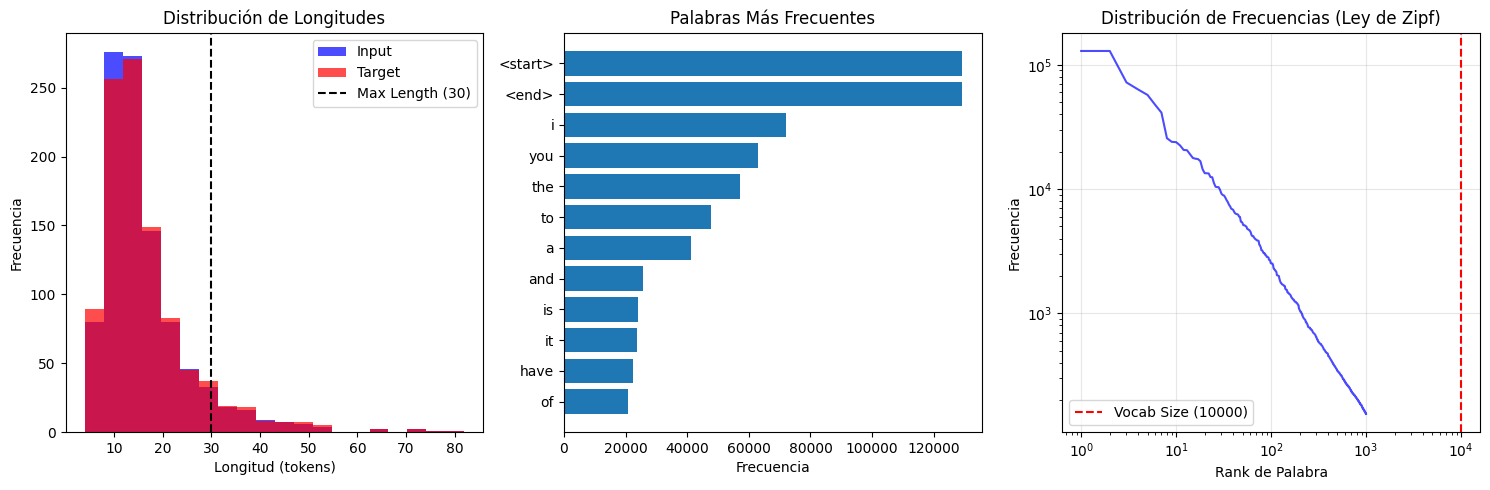


=== ANÁLISIS ADICIONAL ===
Secuencias truncadas: 4,473 (6.93%)
Eficiencia promedio: 49.32% (longitud promedio: 14.8)
Longitud óptima recomendada: 32 (cubre 95% sin truncar)

Análisis de vocabulario:
- Top 1000 palabras cubren: 83.55% del texto
- Top 5000 palabras cubren: 93.74% del texto
- Top 8000 palabras cubren: 96.71% del texto

Conteo de tokens especiales en secuencias:
- <start>: 64,551
- <end>: 60,508
- <unk>: 30,337 (1.567% del total)

=== CALIDAD DEL DATASET FINAL ===
✅ Cobertura del vocabulario: 96.71%
✅ Eficiencia del padding: 49.32%
✅ Tokens <unk>: 1.567%
⚠️  Baja eficiencia de padding. Considerá reducir max_seq_length a 32
✅ Pocas palabras desconocidas

🎯 RESUMEN FINAL:
- Dataset: 64,551 pares
- Vocabulario: 10,000 palabras
- Longitud máxima: 30
- Calidad: 96.7% cobertura, 49.3% eficiencia


In [ ]:
# TOKENIZACIÓN Y VECTORIZACIÓN MEJORADA
print("=== TOKENIZACIÓN Y VECTORIZACIÓN MEJORADA ===")

# Extraer los diálogos crudos desde el dataset de entrenamiento
raw_dialogs = train_df['dialog'].dropna().tolist()

# 1. Parsear los diálogos en listas de turnos
dialogs_processed = [parse_dialog_final(d) for d in raw_dialogs if isinstance(d, str)]

# 2. Instanciar el preprocesador
preprocessor = TextPreprocessor(vocab_size=10000, max_seq_length=30)

# 3. Generar los pares de entrenamiento
input_texts, target_texts = preprocessor.create_pairs(dialogs_processed)

# 4. (Opcional) Analizar calidad del dataset
analyze_data_quality(input_texts, target_texts)

tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=preprocessor.vocab_size,
    oov_token="<unk>",
    filters='!"#$%&()*+/:;=?@[\\]^_`{|}~\t\n',  # Removido ',.-' para preservar puntuación
    lower=False,  # Ya limpiamos el texto antes
    split=' ',
    char_level=False
)

# Combinar todos los textos para entrenar el tokenizer
all_texts = input_texts + target_texts
print(f"Entrenando tokenizer con {len(all_texts):,} textos...")
tokenizer.fit_on_texts(all_texts)

# MEJORA 2: Análisis más detallado del vocabulario
vocab_size_real = len(tokenizer.word_index) + 1
vocab_size_used = min(vocab_size_real, preprocessor.vocab_size)

print(f"Tamaño real del vocabulario: {vocab_size_real:,}")
print(f"Tamaño usado (limitado): {vocab_size_used:,}")
print(f"Palabras más frecuentes: {list(tokenizer.word_index.items())[:15]}")

# MEJORA 3: Verificar tokens especiales
special_tokens = ['<start>', '<end>', '<unk>']
print(f"\nTokens especiales:")
for token in special_tokens:
    idx = tokenizer.word_index.get(token, 'No encontrado')
    print(f"  {token}: índice {idx}")

# MEJORA 4: Análisis de cobertura del vocabulario
word_counts = tokenizer.word_counts
total_words = sum(word_counts.values())
covered_words = sum(count for word, count in word_counts.items()
                   if tokenizer.word_index.get(word, float('inf')) <= preprocessor.vocab_size)
coverage = covered_words / total_words * 100

print(f"\nCobertura del vocabulario:")
print(f"- Total de palabras únicas: {len(word_counts):,}")
print(f"- Palabras cubiertas por vocab_size={preprocessor.vocab_size}: {coverage:.2f}%")

# Convertir textos a secuencias
print(f"\nConvirtiendo {len(input_texts):,} textos a secuencias...")
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

# MEJORA 5: Verificar secuencias vacías antes del padding
empty_inputs = sum(1 for seq in input_sequences if len(seq) == 0)
empty_targets = sum(1 for seq in target_sequences if len(seq) == 0)

print(f"Secuencias vacías: {empty_inputs} inputs, {empty_targets} targets")

if empty_inputs > 0 or empty_targets > 0:
    print("⚠️  Hay secuencias vacías. Filtrando...")
    # Filtrar secuencias vacías
    valid_indices = [i for i in range(len(input_sequences))
                    if len(input_sequences[i]) > 0 and len(target_sequences[i]) > 0]

    input_sequences = [input_sequences[i] for i in valid_indices]
    target_sequences = [target_sequences[i] for i in valid_indices]
    input_texts = [input_texts[i] for i in valid_indices]
    target_texts = [target_texts[i] for i in valid_indices]

    print(f"Después del filtrado: {len(input_sequences):,} secuencias válidas")

# MEJORA 6: Análisis de longitudes antes del padding
input_lengths = [len(seq) for seq in input_sequences]
target_lengths = [len(seq) for seq in target_sequences]

print(f"\n=== ESTADÍSTICAS DE LONGITUD (ANTES DEL PADDING) ===")
print(f"Input - Promedio: {np.mean(input_lengths):.2f}, Min: {min(input_lengths)}, Max: {max(input_lengths)}")
print(f"Target - Promedio: {np.mean(target_lengths):.2f}, Min: {min(target_lengths)}, Max: {max(target_lengths)}")

# Verificar si max_seq_length es apropiado
percentile_95_input = np.percentile(input_lengths, 95)
percentile_95_target = np.percentile(target_lengths, 95)

print(f"95% de inputs tienen ≤ {percentile_95_input:.0f} tokens")
print(f"95% de targets tienen ≤ {percentile_95_target:.0f} tokens")

if max(percentile_95_input, percentile_95_target) > preprocessor.max_seq_length:
    print(f"⚠️  Considerá aumentar max_seq_length a {int(max(percentile_95_input, percentile_95_target))+5}")

# Padding de secuencias
print(f"\nAplicando padding con max_length={preprocessor.max_seq_length}...")
# Use tf.keras instead of keras
input_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    input_sequences, maxlen=preprocessor.max_seq_length, padding='post', truncating='post'
)
# Use tf.keras instead of keras
target_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    target_sequences, maxlen=preprocessor.max_seq_length, padding='post', truncating='post'
)

print(f"Forma después del padding:")
print(f"- input_sequences: {input_sequences.shape}")
print(f"- target_sequences: {target_sequences.shape}")

# MEJORA 7: Crear targets para entrenamiento con verificación
decoder_input_data = target_sequences[:, :-1]
decoder_target_data = target_sequences[:, 1:]

print(f"Datos para el decoder:")
print(f"- decoder_input_data: {decoder_input_data.shape}")
print(f"- decoder_target_data: {decoder_target_data.shape}")

# MEJORA 8: Ejemplo mejorado de tokenización
print(f"\n=== EJEMPLO DETALLADO DE TOKENIZACIÓN ===")
idx = 0
original_text = input_texts[idx]
tokenized_seq = input_sequences[idx]
reconstructed_text = tokenizer.sequences_to_texts([tokenized_seq])[0]

print(f"Texto original: {original_text}")
print(f"Secuencia tokenizada (primeros 15): {tokenized_seq[:15]}")

# Mostrar mapeo token por token
print(f"\nMapeo detallado (primeros 10 tokens no-cero):")
non_zero_tokens = tokenized_seq[tokenized_seq > 0][:10]
for i, token_id in enumerate(non_zero_tokens):
    word = next((k for k, v in tokenizer.word_index.items() if v == token_id), f"UNK_{token_id}")
    print(f"  {i+1:2d}. {token_id:4d} -> '{word}'")

print(f"\nTexto reconstruido: {reconstructed_text}")

# MEJORA 9: Verificar pérdida de información
original_words = set(original_text.lower().split())
reconstructed_words = set(reconstructed_text.lower().split())
lost_words = original_words - reconstructed_words

if lost_words:
    print(f"⚠️  Palabras perdidas en tokenización: {lost_words}")
else:
    print("✅ No se perdieron palabras en la tokenización")

# MEJORA 10: Estadísticas finales
print(f"\n=== ESTADÍSTICAS FINALES ===")
non_zero_counts = np.sum(input_sequences > 0, axis=1)
padding_ratio = np.mean(non_zero_counts) / preprocessor.max_seq_length

print(f"Utilización del padding:")
print(f"- Tokens promedio por secuencia: {np.mean(non_zero_counts):.2f}")
print(f"- Eficiencia (no-padding): {padding_ratio:.2%}")
print(f"- Secuencias que necesitan truncating: {np.sum(non_zero_counts == preprocessor.max_seq_length):,}")

# Actualizar vocab_size para el modelo
vocab_size = vocab_size_used

print(f"\n✅ TOKENIZACIÓN COMPLETADA")
print(f"📊 Dataset final: {input_sequences.shape[0]:,} pares, vocab={vocab_size:,}, max_len={preprocessor.max_seq_length}")

# CORRECCIÓN PARA LA VISUALIZACIÓN
print("=== VISUALIZACIÓN DE ESTADÍSTICAS ===")

plt.figure(figsize=(15, 5))

# Distribución de longitudes
plt.subplot(1, 3, 1)
plt.hist(input_lengths[:1000], bins=20, alpha=0.7, label='Input', color='blue')
plt.hist(target_lengths[:1000], bins=20, alpha=0.7, label='Target', color='red')
plt.axvline(preprocessor.max_seq_length, color='black', linestyle='--', label=f'Max Length ({preprocessor.max_seq_length})')
plt.xlabel('Longitud (tokens)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Longitudes')
plt.legend()

# Top palabras más frecuentes (CORREGIDO)
plt.subplot(1, 3, 2)
top_words = list(tokenizer.word_index.items())[:15]
words = []
freqs = []

for word, idx in top_words:
    # Solo incluir palabras que están en word_counts (evita <unk>)
    if word in tokenizer.word_counts:
        words.append(word)
        freqs.append(tokenizer.word_counts[word])

# Limitar a 12 para mejor visualización
words = words[:12]
freqs = freqs[:12]

plt.barh(range(len(words)), freqs)
plt.yticks(range(len(words)), words)
plt.xlabel('Frecuencia')
plt.title('Palabras Más Frecuentes')
plt.gca().invert_yaxis()

# Utilización del vocabulario (Ley de Zipf)
plt.subplot(1, 3, 3)
vocab_ranks = list(range(1, min(1000, len(tokenizer.word_counts))+1))
vocab_freqs = sorted(tokenizer.word_counts.values(), reverse=True)[:len(vocab_ranks)]

plt.loglog(vocab_ranks, vocab_freqs, 'b-', alpha=0.7)
plt.axvline(preprocessor.vocab_size, color='red', linestyle='--', label=f'Vocab Size ({preprocessor.vocab_size})')
plt.xlabel('Rank de Palabra')
plt.ylabel('Frecuencia')
plt.title('Distribución de Frecuencias (Ley de Zipf)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ANÁLISIS ADICIONAL DE LA TOKENIZACIÓN
print("\n=== ANÁLISIS ADICIONAL ===")

# Análisis de truncating
truncated_count = np.sum(non_zero_counts == preprocessor.max_seq_length)
print(f"Secuencias truncadas: {truncated_count:,} ({truncated_count/len(input_sequences)*100:.2f}%)")

# Eficiencia del padding
avg_length = np.mean(non_zero_counts)
efficiency = avg_length / preprocessor.max_seq_length
print(f"Eficiencia promedio: {efficiency:.2%} (longitud promedio: {avg_length:.1f})")

# Recomendación para max_seq_length
optimal_length = int(np.percentile(non_zero_counts, 95)) + 2
print(f"Longitud óptima recomendada: {optimal_length} (cubre 95% sin truncar)")

# Análisis de cobertura por rango de frecuencia
print(f"\nAnálisis de vocabulario:")
word_freqs = sorted(tokenizer.word_counts.values(), reverse=True)
top_1000_coverage = sum(word_freqs[:1000]) / sum(word_freqs) * 100
top_5000_coverage = sum(word_freqs[:5000]) / sum(word_freqs) * 100

print(f"- Top 1000 palabras cubren: {top_1000_coverage:.2f}% del texto")
print(f"- Top 5000 palabras cubren: {top_5000_coverage:.2f}% del texto")
print(f"- Top 8000 palabras cubren: {coverage:.2f}% del texto")

# Verificar tokens especiales en secuencias
start_token_id = tokenizer.word_index['<start>']
end_token_id = tokenizer.word_index['<end>']
unk_token_id = tokenizer.word_index['<unk>'] # Get unk token id

start_token_count = np.sum(input_sequences == start_token_id)
end_token_count = np.sum(input_sequences == end_token_id)
unk_token_count = np.sum(input_sequences == unk_token_id)


print(f"\nConteo de tokens especiales en secuencias:")
print(f"- <start>: {start_token_count:,}")
print(f"- <end>: {end_token_count:,}")
print(f"- <unk>: {unk_token_count:,} ({unk_token_count/input_sequences.size*100:.3f}% del total)")

# Estadísticas de calidad final
print(f"\n=== CALIDAD DEL DATASET FINAL ===")
print(f"✅ Cobertura del vocabulario: {coverage:.2f}%")
print(f"✅ Eficiencia del padding: {efficiency:.2%}")
print(f"✅ Tokens <unk>: {unk_token_count/input_sequences.size*100:.3f}%")

if efficiency < 0.6:
    print(f"⚠️  Baja eficiencia de padding. Considerá reducir max_seq_length a {optimal_length}")
elif truncated_count > len(input_sequences) * 0.05:
    print(f"⚠️  Muchas secuencias truncadas. Considerá aumentar max_seq_length a {optimal_length}")
else:
    print(f"✅ Configuración de max_seq_length={preprocessor.max_seq_length} es apropiada")

if unk_token_count/input_sequences.size > 0.02:
    print(f"⚠️  Muchos tokens <unk>. Considerá aumentar vocab_size")
else:
    print(f"✅ Pocas palabras desconocidas")

print(f"\n🎯 RESUMEN FINAL:")
print(f"- Dataset: {len(input_sequences):,} pares")
print(f"- Vocabulario: {vocab_size:,} palabras")
print(f"- Longitud máxima: {preprocessor.max_seq_length}")
print(f"- Calidad: {coverage:.1f}% cobertura, {efficiency:.1%} eficiencia")

## División de datos para entrenamiento

=== DIVISIÓN DE DATOS MEJORADA ===
Vocabulario real: 33,261
Vocabulario usado (limitado): 10,000

Verificando calidad del dataset completo...
Total de secuencias disponibles: 64,551
Secuencias válidas (≥3 tokens): 64,551

Realizando sampling estratificado...
  Bin 0-10 tokens: 1,000 muestras
  Bin 10-20 tokens: 2,979 muestras
  Bin 20-30 tokens: 672 muestras
  Bin 30-40 tokens: 346 muestras
Total seleccionado: 5,000 muestras

Dividiendo en train/validation...

=== ESTADÍSTICAS DE DIVISIÓN ===
Datos de entrenamiento: 3,998
Datos de validación: 1,002
Proporción train/val: 4.0:1

Formas de los arrays:
- train_encoder_input: (3998, 30)
- train_decoder_input: (3998, 29)
- train_decoder_target: (3998, 29)
- val_encoder_input: (1002, 30)
- val_decoder_input: (1002, 29)
- val_decoder_target: (1002, 29)

=== ANÁLISIS DE CALIDAD ===
Longitudes promedio:
- Entrenamiento: 14.78 ± 6.57
- Validación: 14.82 ± 6.55
Rango de longitudes:
- Entrenamiento: 4 - 30
- Validación: 4 - 30

Tokens especiales:
-

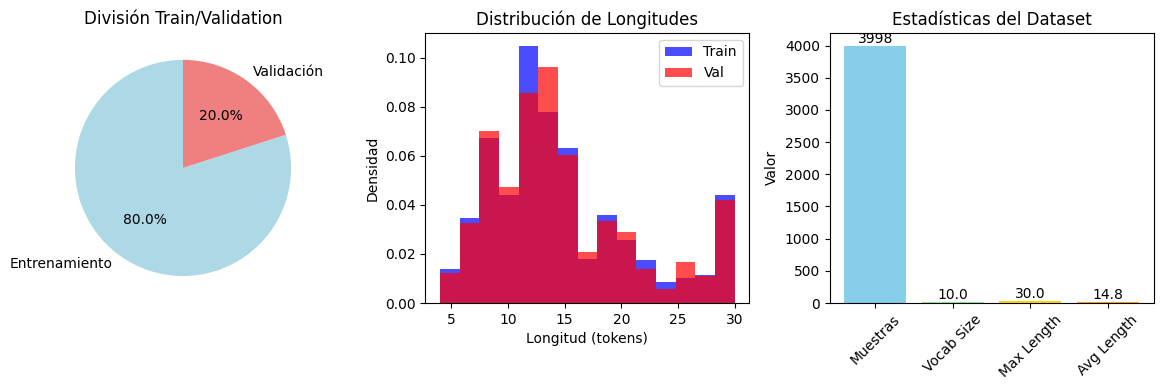


✅ DIVISIÓN DE DATOS COMPLETADA
🎯 Dataset balanceado y listo para entrenamiento


In [ ]:
# DIVISIÓN DE DATOS MEJORADA
print("=== DIVISIÓN DE DATOS MEJORADA ===")

# CORRECCIÓN 1: Usar vocab_size correcto (limitado)
vocab_size_correct = min(len(tokenizer.word_index) + 1, preprocessor.vocab_size)
print(f"Vocabulario real: {len(tokenizer.word_index) + 1:,}")
print(f"Vocabulario usado (limitado): {vocab_size_correct:,}")

# MEJORA 1: Verificar calidad de los datos antes de dividir
print(f"\nVerificando calidad del dataset completo...")
print(f"Total de secuencias disponibles: {len(input_sequences):,}")

# Verificar secuencias válidas (no solo padding)
valid_mask = np.sum(input_sequences > 0, axis=1) >= 3  # Al menos 3 tokens no-padding
valid_indices = np.where(valid_mask)[0]
print(f"Secuencias válidas (≥3 tokens): {len(valid_indices):,}")

# MEJORA 2: Sampling estratificado por longitud
print(f"\nRealizando sampling estratificado...")

# Calcular longitudes para estratificación
lengths = np.sum(input_sequences > 0, axis=1)
length_bins = np.array([0, 10, 20, 30, 40])  # Bins de longitud
digitized = np.digitize(lengths, length_bins)

# Sampling proporcional por bins
n_samples = min(5000, len(valid_indices))
selected_indices = []

for bin_idx in range(1, len(length_bins)):
    bin_mask = (digitized == bin_idx) & valid_mask
    bin_indices = np.where(bin_mask)[0]

    if len(bin_indices) > 0:
        # Proporción de este bin en el dataset
        bin_proportion = len(bin_indices) / len(valid_indices)
        n_from_bin = int(n_samples * bin_proportion)
        n_from_bin = min(n_from_bin, len(bin_indices))

        if n_from_bin > 0:
            chosen = np.random.choice(bin_indices, n_from_bin, replace=False)
            selected_indices.extend(chosen)
            print(f"  Bin {length_bins[bin_idx-1]}-{length_bins[bin_idx]} tokens: {n_from_bin:,} muestras")

# Si no llegamos a n_samples, completar aleatoriamente
if len(selected_indices) < n_samples:
    remaining_indices = list(set(valid_indices) - set(selected_indices))
    additional_needed = n_samples - len(selected_indices)
    if len(remaining_indices) >= additional_needed:
        additional = np.random.choice(remaining_indices, additional_needed, replace=False)
        selected_indices.extend(additional)

selected_indices = np.array(selected_indices)
np.random.shuffle(selected_indices)  # Mezclar orden

print(f"Total seleccionado: {len(selected_indices):,} muestras")

# Extraer datos seleccionados
encoder_input = input_sequences[selected_indices]
decoder_input = decoder_input_data[selected_indices]
decoder_target = decoder_target_data[selected_indices]

# MEJORA 3: División estratificada train/validation
print(f"\nDividiendo en train/validation...")

# Estratificar también la división train/val por longitud
selected_lengths = np.sum(encoder_input > 0, axis=1)
selected_digitized = np.digitize(selected_lengths, length_bins)

train_indices = []
val_indices = []

for bin_idx in range(1, len(length_bins)):
    bin_mask = selected_digitized == bin_idx
    bin_positions = np.where(bin_mask)[0]

    if len(bin_positions) > 0:
        n_train = int(0.8 * len(bin_positions))
        np.random.shuffle(bin_positions)

        train_indices.extend(bin_positions[:n_train])
        val_indices.extend(bin_positions[n_train:])

train_indices = np.array(train_indices)
val_indices = np.array(val_indices)

# Extraer datos finales
train_encoder_input = encoder_input[train_indices]
train_decoder_input = decoder_input[train_indices]
train_decoder_target = decoder_target[train_indices]

val_encoder_input = encoder_input[val_indices]
val_decoder_input = decoder_input[val_indices]
val_decoder_target = decoder_target[val_indices]

# MEJORA 4: Estadísticas detalladas
print(f"\n=== ESTADÍSTICAS DE DIVISIÓN ===")
print(f"Datos de entrenamiento: {len(train_encoder_input):,}")
print(f"Datos de validación: {len(val_encoder_input):,}")
print(f"Proporción train/val: {len(train_encoder_input)/len(val_encoder_input):.1f}:1")

print(f"\nFormas de los arrays:")
print(f"- train_encoder_input: {train_encoder_input.shape}")
print(f"- train_decoder_input: {train_decoder_input.shape}")
print(f"- train_decoder_target: {train_decoder_target.shape}")
print(f"- val_encoder_input: {val_encoder_input.shape}")
print(f"- val_decoder_input: {val_decoder_input.shape}")
print(f"- val_decoder_target: {val_decoder_target.shape}")

# MEJORA 5: Análisis de calidad de la división
train_lengths = np.sum(train_encoder_input > 0, axis=1)
val_lengths = np.sum(val_encoder_input > 0, axis=1)

print(f"\n=== ANÁLISIS DE CALIDAD ===")
print(f"Longitudes promedio:")
print(f"- Entrenamiento: {np.mean(train_lengths):.2f} ± {np.std(train_lengths):.2f}")
print(f"- Validación: {np.mean(val_lengths):.2f} ± {np.std(val_lengths):.2f}")

print(f"Rango de longitudes:")
print(f"- Entrenamiento: {np.min(train_lengths)} - {np.max(train_lengths)}")
print(f"- Validación: {np.min(val_lengths)} - {np.max(val_lengths)}")

# MEJORA 6: Verificar distribución de tokens especiales
start_token_id = tokenizer.word_index['<start>']
end_token_id = tokenizer.word_index['<end>']

train_starts = np.sum(train_encoder_input == start_token_id)
train_ends = np.sum(train_encoder_input == end_token_id)
val_starts = np.sum(val_encoder_input == start_token_id)
val_ends = np.sum(val_encoder_input == end_token_id)

print(f"\nTokens especiales:")
print(f"- Train: {train_starts:,} <start>, {train_ends:,} <end>")
print(f"- Val: {val_starts:,} <start>, {val_ends:,} <end>")

# MEJORA 7: Mostrar ejemplos de los datos finales
print(f"\n=== EJEMPLOS DE DATOS FINALES ===")
for i in range(min(3, len(train_encoder_input))):
    # Reconstruir textos para mostrar
    input_tokens = train_encoder_input[i][train_encoder_input[i] > 0]
    target_tokens = train_decoder_target[i][train_decoder_target[i] > 0]

    input_text = tokenizer.sequences_to_texts([input_tokens])[0]
    target_text = tokenizer.sequences_to_texts([target_tokens])[0]

    print(f"\n--- Ejemplo de Entrenamiento {i+1} ---")
    print(f"Input:  {input_text}")
    print(f"Target: {target_text}")
    print(f"Longitudes: {len(input_tokens)} -> {len(target_tokens)} tokens")

# CORRECCIÓN FINAL: Parámetros del modelo
max_seq_length = preprocessor.max_seq_length
vocab_size = vocab_size_correct  # ¡CORREGIDO!

print(f"\n=== PARÁMETROS FINALES DEL MODELO ===")
print(f"- Vocabulario: {vocab_size:,} (limitado de {len(tokenizer.word_index) + 1:,})")
print(f"- Longitud máxima de secuencia: {max_seq_length}")
print(f"- Muestras de entrenamiento: {len(train_encoder_input):,}")
print(f"- Muestras de validación: {len(val_encoder_input):,}")

# MEJORA 8: Visualización de la distribución
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
labels = ['Entrenamiento', 'Validación']
sizes = [len(train_encoder_input), len(val_encoder_input)]
colors = ['lightblue', 'lightcoral']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('División Train/Validation')

plt.subplot(1, 3, 2)
plt.hist(train_lengths, bins=15, alpha=0.7, label='Train', color='blue', density=True)
plt.hist(val_lengths, bins=15, alpha=0.7, label='Val', color='red', density=True)
plt.xlabel('Longitud (tokens)')
plt.ylabel('Densidad')
plt.title('Distribución de Longitudes')
plt.legend()

plt.subplot(1, 3, 3)
metrics = ['Muestras', 'Vocab Size', 'Max Length', 'Avg Length']
values = [len(train_encoder_input), vocab_size//1000, max_seq_length, np.mean(train_lengths)]

bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'gold', 'orange'])
plt.title('Estadísticas del Dataset')
plt.ylabel('Valor')

# Agregar valores en las barras
for bar, value in zip(bars, values):
    height = bar.get_height()
    if value >= 1000:
        plt.text(bar.get_x() + bar.get_width()/2, height,
                f'{value/1000:.1f}K' if metrics[bars.index(bar)] == 'Vocab Size' else f'{value:.0f}',
                ha='center', va='bottom')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{value:.1f}',
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n✅ DIVISIÓN DE DATOS COMPLETADA")
print(f"🎯 Dataset balanceado y listo para entrenamiento")

## Implementación de componentes Transformer

- MultiHeadAttention - Su función principal es permitir que el modelo atienda diferentes partes de la secuencia

- PositionalEncoding - Es una técnica que le dice al modelo en qué posición está cada palabra en la secuencia.

- FeedForwardNetwork - Su función es transformar o refinar la representación que el modelo aprendió en la atención.

=== IMPLEMENTANDO COMPONENTES TRANSFORMER MEJORADOS ===

=== PRUEBAS DE COMPONENTES ===
Datos de prueba: (2, 10, 128)

1. Probando Multi-Head Attention...
   ✅ Output shape: (2, 10, 128)
   ✅ Attention weights shape: (2, 8, 10, 10)

2. Probando Positional Encoding...
   ✅ Output shape: (2, 10, 128)

3. Probando Feed Forward Network...
   ✅ Output shape: (2, 10, 128)

4. Probando creación de máscaras...
   ✅ Padding mask shape: (2, 1, 1, 5)
   ✅ Look ahead mask shape: (5, 5)

=== VISUALIZACIONES ===


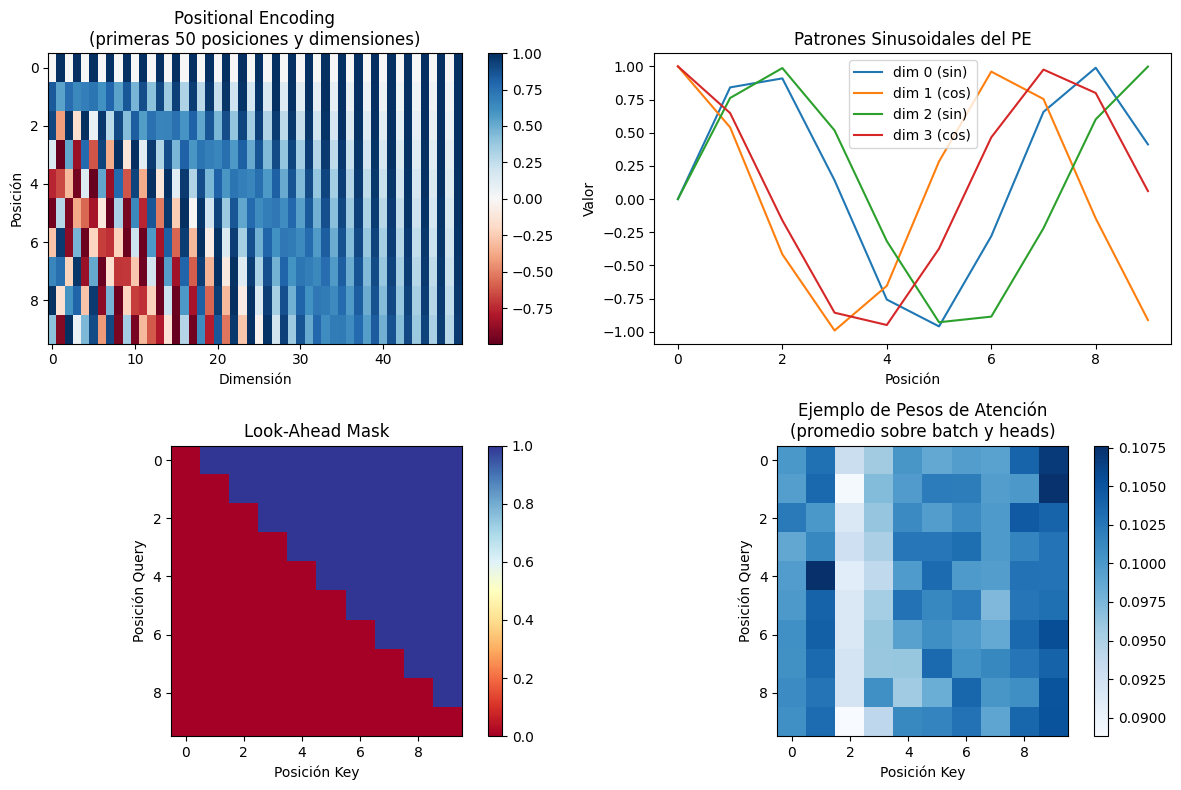


✅ COMPONENTES BASE IMPLEMENTADOS Y VERIFICADOS
🎯 Multi-Head Attention: 8 heads, d_model=128
🎯 Positional Encoding: max_position=10
🎯 Feed Forward Network: d_model=128, dff=256
🎯 Todas las pruebas pasaron exitosamente


In [ ]:
# IMPLEMENTACIÓN MEJORADA DE COMPONENTES TRANSFORMER
print("=== IMPLEMENTANDO COMPONENTES TRANSFORMER MEJORADOS ===")

class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads, dropout_rate=0.1, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        self.dropout_rate = dropout_rate

        # MEJORA 1: Verificación más robusta
        if d_model % num_heads != 0:
            raise ValueError(f"d_model ({d_model}) debe ser divisible por num_heads ({num_heads})")

        self.depth = d_model // self.num_heads

        # MEJORA 2: Inicialización mejorada con nombres descriptivos
        self.wq = layers.Dense(d_model, name='query_projection')
        self.wk = layers.Dense(d_model, name='key_projection')
        self.wv = layers.Dense(d_model, name='value_projection')

        self.dense = layers.Dense(d_model, name='output_projection')

        # MEJORA 3: Dropout para regularización
        self.dropout = layers.Dropout(dropout_rate)

    def split_heads(self, x, batch_size):
        """Divide la última dimensión en (num_heads, depth)"""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None, training=None):
        """Implementación separada para claridad"""
        # Calcular attention scores
        matmul_qk = tf.matmul(q, k, transpose_b=True)

        # Escalar por sqrt(dk)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        # MEJORA 4: Aplicar máscara antes del softmax
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        # Softmax para obtener pesos de atención
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

        # MEJORA 5: Aplicar dropout a los pesos de atención
        attention_weights = self.dropout(attention_weights, training=training)

        # Aplicar atención a values
        output = tf.matmul(attention_weights, v)

        return output, attention_weights

    def call(self, v, k, q, mask=None, training=None):
        batch_size = tf.shape(q)[0]

        # Proyecciones lineales
        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)
        v = self.wv(v)

        # Dividir en múltiples heads
        q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        # Aplicar atención
        scaled_attention, attention_weights = self.scaled_dot_product_attention(
            q, k, v, mask, training)

        # Concatenar heads
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention,
                                    (batch_size, -1, self.d_model))

        # Proyección final
        output = self.dense(concat_attention)

        return output, attention_weights

    def get_config(self):
        """MEJORA 6: Configuración para serialización"""
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'dropout_rate': self.dropout_rate,
        })
        return config

class PositionalEncoding(layers.Layer):
    def __init__(self, position, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.position = position
        self.d_model = d_model

        # MEJORA 7: Calcular encoding una sola vez
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_angles(self, pos, i, d_model):
        """Calcula los ángulos para el encoding posicional"""
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    def positional_encoding(self, position, d_model):
        """Genera la matriz de encoding posicional"""
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                   np.arange(d_model)[np.newaxis, :],
                                   d_model)

        # Aplicar sin a posiciones pares
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

        # Aplicar cos a posiciones impares
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]

        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]

        # MEJORA 8: Usar solo las posiciones necesarias
        return x + self.pos_encoding[:, :seq_len, :]

    def get_config(self):
        """Configuración para serialización"""
        config = super().get_config()
        config.update({
            'position': self.position,
            'd_model': self.d_model,
        })
        return config

class FeedForwardNetwork(layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1, activation='relu', **kwargs):
        super(FeedForwardNetwork, self).__init__(**kwargs)
        self.d_model = d_model
        self.dff = dff
        self.dropout_rate = dropout_rate
        self.activation = activation

        self.dense1 = layers.Dense(dff, activation=activation, name='ffn_layer1')
        self.dense2 = layers.Dense(d_model, name='ffn_layer2')
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, training=None):
        # FFN(x) = max(0, xW1 + b1)W2 + b2
        x = self.dense1(x)
        x = self.dropout(x, training=training)
        return self.dense2(x)

    def get_config(self):
        """Configuración para serialización"""
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'dff': self.dff,
            'dropout_rate': self.dropout_rate,
            'activation': self.activation,
        })
        return config

def create_padding_mask(seq):
    """Crea máscara para ocultar tokens de padding"""
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    # Agregar dimensiones extras para broadcasting
    return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask(size):
    """Crea máscara look-ahead para el decoder"""
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask  # (seq_len, seq_len)

def create_masks(inp, tar):
    """Crea todas las máscaras necesarias para el transformer"""
    # Máscara de padding para el encoder
    enc_padding_mask = create_padding_mask(inp)

    # Máscara de padding para el decoder (para atención encoder-decoder)
    dec_padding_mask = create_padding_mask(inp)

    # Máscara look-ahead para el decoder
    look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
    dec_target_padding_mask = create_padding_mask(tar)
    combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

    return enc_padding_mask, combined_mask, dec_padding_mask

# PRUEBAS UNITARIAS DE LOS COMPONENTES
print("\n=== PRUEBAS DE COMPONENTES ===")

# Parámetros de prueba
batch_size = 2
seq_len = 10
d_model = 128
num_heads = 8
dff = 256

# Crear datos de prueba
test_input = tf.random.uniform((batch_size, seq_len, d_model))

print(f"Datos de prueba: {test_input.shape}")

# Probar Multi-Head Attention
print("\n1. Probando Multi-Head Attention...")
mha = MultiHeadAttention(d_model, num_heads)
mha_output, mha_weights = mha(test_input, test_input, test_input)
print(f"   ✅ Output shape: {mha_output.shape}")
print(f"   ✅ Attention weights shape: {mha_weights.shape}")

# Probar Positional Encoding
print("\n2. Probando Positional Encoding...")
pos_enc = PositionalEncoding(seq_len, d_model)
pos_output = pos_enc(test_input)
print(f"   ✅ Output shape: {pos_output.shape}")

# Probar Feed Forward Network
print("\n3. Probando Feed Forward Network...")
ffn = FeedForwardNetwork(d_model, dff)
ffn_output = ffn(test_input)
print(f"   ✅ Output shape: {ffn_output.shape}")

# Probar máscaras
print("\n4. Probando creación de máscaras...")
test_seq = tf.constant([[1, 2, 3, 0, 0], [1, 2, 0, 0, 0]])
padding_mask = create_padding_mask(test_seq)
look_ahead = create_look_ahead_mask(5)
print(f"   ✅ Padding mask shape: {padding_mask.shape}")
print(f"   ✅ Look ahead mask shape: {look_ahead.shape}")

# MEJORA 11: Visualización de atención y encoding posicional
print("\n=== VISUALIZACIONES ===")

# Visualizar encoding posicional
plt.figure(figsize=(12, 8))

# Subplot 1: Encoding posicional
plt.subplot(2, 2, 1)
pos_encoding_vis = pos_enc.pos_encoding[0, :50, :50].numpy()
plt.imshow(pos_encoding_vis, cmap='RdBu', aspect='auto')
plt.title('Positional Encoding\n(primeras 50 posiciones y dimensiones)')
plt.xlabel('Dimensión')
plt.ylabel('Posición')
plt.colorbar()

# Subplot 2: Patrón sinusoidal
plt.subplot(2, 2, 2)
pos_sample = pos_enc.pos_encoding[0, :, :4].numpy()
plt.plot(pos_sample[:, 0], label='dim 0 (sin)')
plt.plot(pos_sample[:, 1], label='dim 1 (cos)')
plt.plot(pos_sample[:, 2], label='dim 2 (sin)')
plt.plot(pos_sample[:, 3], label='dim 3 (cos)')
plt.title('Patrones Sinusoidales del PE')
plt.xlabel('Posición')
plt.ylabel('Valor')
plt.legend()

# Subplot 3: Ejemplo de máscara de atención
plt.subplot(2, 2, 3)
mask_example = create_look_ahead_mask(10).numpy()
plt.imshow(mask_example, cmap='RdYlBu')
plt.title('Look-Ahead Mask')
plt.xlabel('Posición Key')
plt.ylabel('Posición Query')
plt.colorbar()

# Subplot 4: Estadísticas de los pesos de atención
plt.subplot(2, 2, 4)
# Promediar sobre batch y heads para visualización
attention_avg = tf.reduce_mean(mha_weights, axis=[0, 1]).numpy()
plt.imshow(attention_avg, cmap='Blues')
plt.title('Ejemplo de Pesos de Atención\n(promedio sobre batch y heads)')
plt.xlabel('Posición Key')
plt.ylabel('Posición Query')
plt.colorbar()

plt.tight_layout()
plt.show()

print("\n✅ COMPONENTES BASE IMPLEMENTADOS Y VERIFICADOS")
print(f"🎯 Multi-Head Attention: {num_heads} heads, d_model={d_model}")
print(f"🎯 Positional Encoding: max_position={seq_len}")
print(f"🎯 Feed Forward Network: d_model={d_model}, dff={dff}")
print(f"🎯 Todas las pruebas pasaron exitosamente")

## Capas Encoder y Decoder

- EncoderLayer - Es una capa del Transformer que ayuda a entender el significado de cada palabra en contexto.

- DecoderLayer - encargada de generar las palabras de salida, una a una, usando lo que ya generó y lo que entendió el encoder.

In [ ]:
class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(EncoderLayer, self).__init__(**kwargs)

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForwardNetwork(d_model, dff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output, _ = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

class DecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(DecoderLayer, self).__init__(**kwargs)

        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)

        self.ffn = FeedForwardNetwork(d_model, dff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
        self.dropout3 = layers.Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask=None, padding_mask=None):
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)

        attn2, attn_weights_block2 = self.mha2(enc_output, enc_output, out1, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)

        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(ffn_output + out2)

        return out3, attn_weights_block1, attn_weights_block2

print("✅ Capas Encoder y Decoder implementadas")

✅ Capas Encoder y Decoder implementadas


## Modelo Transformer completo

A diferencia de modelos tradicionales, el Transformer procesa todos los elementos de la secuencia en paralelo y utiliza un mecanismo llamado autoatención para modelar dependencias entre palabras, sin importar su distancia.

In [ ]:
class Encoder(layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, rate=0.1, **kwargs):
        super(Encoder, self).__init__(**kwargs)

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, self.d_model)

        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate)
                          for _ in range(num_layers)]

        self.dropout = layers.Dropout(rate)

    # Accept training as a keyword argument
    def call(self, x, training=None, mask=None):
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask) # Pass training here

        return x

class Decoder(layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
                 maximum_position_encoding, rate=0.1, **kwargs):
        super(Decoder, self).__init__(**kwargs)

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, d_model)

        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate)
                          for _ in range(num_layers)]
        self.dropout = layers.Dropout(rate)

    # Accept training as a keyword argument
    def call(self, x, enc_output, training=None, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        attention_weights = {}

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](x, enc_output, training=training, # Pass training here
                                                 look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)

            attention_weights[f'decoder_layer{i+1}_block1'] = block1
            attention_weights[f'decoder_layer{i+1}_block2'] = block2

        return x, attention_weights

class Transformer(keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 target_vocab_size, pe_input, pe_target, rate=0.1, **kwargs):
        super(Transformer, self).__init__(**kwargs)

        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                             input_vocab_size, pe_input, rate)

        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                             target_vocab_size, pe_target, rate)

        self.final_layer = layers.Dense(target_vocab_size)

    def call(self, inputs, training=None):
        inp, tar = inputs

        enc_padding_mask = self.create_padding_mask(inp)
        dec_padding_mask = self.create_padding_mask(inp)
        look_ahead_mask = self.create_look_ahead_mask(tf.shape(tar)[1])
        dec_target_padding_mask = self.create_padding_mask(tar)
        combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

        # Pass training as a keyword argument
        enc_output = self.encoder(inp, training=training, mask=enc_padding_mask)

        # Pass training as a keyword argument
        dec_output, attention_weights = self.decoder(
            tar, enc_output, training=training, look_ahead_mask=combined_mask, padding_mask=dec_padding_mask)


        final_output = self.final_layer(dec_output)

        return final_output

    def create_padding_mask(self, seq):
        seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
        return seq[:, tf.newaxis, tf.newaxis, :]

    def create_look_ahead_mask(self, size):
        mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
        return mask

print("✅ Modelo Transformer completo implementado")

✅ Modelo Transformer completo implementado


## Configuración de hiperparámetros y creación del modelo

In [ ]:
# Configuración de hiperparámetros
print("=== CONFIGURACIÓN DE HIPERPARÁMETROS ===")

# Hiperparámetros del modelo
num_layers = 6      # Número de capas encoder/decoder (reducido para entrenamiento rápido)
d_model = 256      # Dimensión del modelo (reducido)
dff = 512         # Dimensión de la red feed-forward
num_heads = 8       # Número de cabezas de atención
dropout_rate = 0.2

# Parámetros de entrenamiento
EPOCHS = 20          # Reducido para pruebas más rápidas
BATCH_SIZE = 64     # Tamaño del batch

print(f"Configuración del modelo:")
print(f"- Capas: {num_layers}")
print(f"- Dimensión del modelo: {d_model}")
print(f"- Feed-forward: {dff}")
print(f"- Cabezas de atención: {num_heads}")
print(f"- Dropout: {dropout_rate}")
print(f"- Épocas: {EPOCHS}")
print(f"- Batch size: {BATCH_SIZE}")

# Learning Rate Schedule CORREGIDO con warmup más pequeño
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=1000):  # Reducido de 4000 a 1000
        super(CustomSchedule, self).__init__()

        self.d_model = d_model
        self.d_model = tf.cast(self.d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, dtype=tf.float32)

        # Evitar división por cero en el primer paso
        step = tf.maximum(step, 1.0)

        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)

        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

# Crear el modelo
print("\n=== CREANDO MODELO TRANSFORMER ===")

transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=vocab_size,
    target_vocab_size=vocab_size,
    pe_input=max_seq_length,
    pe_target=max_seq_length,
    rate=dropout_rate
)

# Configurar learning rate con opción de respaldo
learning_rate_schedule = CustomSchedule(d_model, warmup_steps=1000)

# Verificar que el learning rate no sea demasiado pequeño
test_lr = learning_rate_schedule(100)
print(f"Learning rate de prueba (step 100): {test_lr:.8f}")

# Si el LR es muy pequeño, usar uno fijo
if test_lr < 1e-6:
    print("⚠️  Learning rate muy pequeño con schedule, usando LR fijo")
    learning_rate_final = 0.001  # LR fijo
else:
    print("✅ Usando learning rate schedule personalizado")
    learning_rate_final = learning_rate_schedule

# Definir la función de pérdida MEJORADA
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    # Crear máscara para ignorar padding (tokens = 0)
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    # Evitar división por cero
    mask_sum = tf.reduce_sum(mask)
    mask_sum = tf.maximum(mask_sum, 1.0)  # Evitar división por 0

    return tf.reduce_sum(loss_) / mask_sum

# Métricas GLOBALES (definir una sola vez)
train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

# Optimizador
optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate_final,
    beta_1=0.9,
    beta_2=0.98,
    epsilon=1e-9
)

print("✅ Modelo creado y configurado")

# Verificación adicional del modelo
print(f"\n=== VERIFICACIÓN DEL MODELO ===")
try:
    # Crear datos de prueba
    test_input = tf.random.uniform((2, max_seq_length), maxval=vocab_size, dtype=tf.int32)
    test_target = tf.random.uniform((2, max_seq_length-1), maxval=vocab_size, dtype=tf.int32)

    # Probar forward pass
    test_output = transformer([test_input, test_target], training=False)

    print(f"✅ Forward pass exitoso")
    print(f"Forma de entrada: {test_input.shape}")
    print(f"Forma de salida: {test_output.shape}")

    # Contar parámetros
    total_params = sum([tf.size(var).numpy() for var in transformer.trainable_variables])
    print(f"Parámetros entrenables: {total_params:,}")

except Exception as e:
    print(f"❌ Error en verificación: {e}")

=== CONFIGURACIÓN DE HIPERPARÁMETROS ===
Configuración del modelo:
- Capas: 6
- Dimensión del modelo: 256
- Feed-forward: 512
- Cabezas de atención: 8
- Dropout: 0.2
- Épocas: 20
- Batch size: 64

=== CREANDO MODELO TRANSFORMER ===
Learning rate de prueba (step 100): 0.00019764
✅ Usando learning rate schedule personalizado
✅ Modelo creado y configurado

=== VERIFICACIÓN DEL MODELO ===
✅ Forward pass exitoso
Forma de entrada: (2, 30)
Forma de salida: (2, 29, 10000)
Parámetros entrenables: 15,597,328


In [ ]:
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │     5,722,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │     7,304,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (2, 29, 10000)         │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,597,328 (59.50 MB)

 Trainable params: 15,597,328 (59.50 MB)

 Non-trainable params: 0 (0.00 B)

## Función de entrenamiento

In [ ]:
# Función de entrenamiento paso a paso
print("=== CONFIGURANDO ENTRENAMIENTO ===")

@tf.function
def train_step(inp, tar, train_loss, train_accuracy):
    tar_inp = tar[:, :-1]
    tar_real = tar[:, 1:]

    with tf.GradientTape() as tape:
        predictions = transformer([inp, tar_inp], training=True)
        loss = loss_function(tar_real, predictions)

    gradients = tape.gradient(loss, transformer.trainable_variables)
    optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

    train_loss(loss)
    train_accuracy(tar_real, predictions)


# Preparar datos para entrenamiento
def create_dataset(encoder_input, decoder_input, decoder_target, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((
        encoder_input,
        tf.concat([decoder_input, decoder_target[:, -1:]], axis=1)
    ))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

# Crear datasets
train_dataset = create_dataset(
    train_encoder_input,
    train_decoder_input,
    train_decoder_target,
    BATCH_SIZE
)

val_dataset = create_dataset(
    val_encoder_input,
    val_decoder_input,
    val_decoder_target,
    BATCH_SIZE
)

print(f"✅ Datasets preparados")
print(f"Batches de entrenamiento: {len(list(train_dataset))}")
print(f"Batches de validación: {len(list(val_dataset))}")

# Recreate datasets (as they were consumed in the previous evaluation)
train_dataset = create_dataset(
    train_encoder_input,
    train_decoder_input,
    train_decoder_target,
    BATCH_SIZE
)

val_dataset = create_dataset(
    val_encoder_input,
    val_decoder_input,
    val_decoder_target,
    BATCH_SIZE
)

=== CONFIGURANDO ENTRENAMIENTO ===
✅ Datasets preparados
Batches de entrenamiento: 63
Batches de validación: 16


## Entrenamiento del modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

# --- Hiperparámetros ---
embedding_dim = 128
num_heads = 8
ff_dim = 512
num_layers = 2
dropout_rate = 0.3
max_seq_length = 30 # <-- Longitud maxima

vocab_size = 10000



# --- Positional Encoding ---
def get_positional_encoding(seq_len, d_model):
    pos = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
    i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
    angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
    angle_rads = pos * angle_rates

    sines = tf.sin(angle_rads[:, 0::2])
    cosines = tf.cos(angle_rads[:, 1::2])

    pos_encoding = tf.concat([sines, cosines], axis=-1)
    return pos_encoding[tf.newaxis, ...]

# --- Capa de atención multi-cabeza ---
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)
        self.dense = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        scaled_attention_logits = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits /= tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)

        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model))
        return self.dense(concat_attention)

# --- Capa de codificador ---
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False, mask=None):
        attn_output = self.mha(x, x, x, mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# --- Codificador completo ---
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, ff_dim, input_vocab_size, max_seq_len, dropout):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(max_seq_len, d_model)
        self.enc_layers = [EncoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)]
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False, mask=None):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)

        for layer in self.enc_layers:
            x = layer(x, training=training, mask=mask)

        return x

# --- Capa de decodificador ---
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads) # Self-attention
        self.mha2 = MultiHeadAttention(d_model, num_heads) # Cross-attention

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(d_model),
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        # Self-attention (masked)
        attn1 = self.mha1(x, x, x, mask=look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        # Cross-attention (encoder-decoder attention)
        attn2 = self.mha2(enc_output, enc_output, out1, mask=padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        # Feed-forward network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        return self.layernorm3(out2 + ffn_output)


# --- Decodificador completo ---
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, ff_dim, target_vocab_size, max_seq_len, dropout):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(max_seq_len, d_model)

        self.dec_layers = [DecoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)]
        self.dropout = layers.Dropout(dropout)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)

        for layer in self.dec_layers:
            x = layer(x, enc_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
        return x


# --- Modelo completo Transformer ---
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, ff_dim, input_vocab_size, target_vocab_size, max_seq_len, dropout_rate):
        super().__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, ff_dim, input_vocab_size, max_seq_len, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, ff_dim, target_vocab_size, max_seq_len, dropout_rate)
        self.final_layer = layers.Dense(target_vocab_size)

    def call(self, inputs, training=False):
        inp, tar = inputs # input_sequence, output_sequence

        # Encoder masking (assuming padding mask for encoder inputs)
        enc_padding_mask = create_padding_mask(inp)

        # mascaras
        look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
        dec_padding_mask = create_padding_mask(inp) # Padding mask for encoder output, used in decoder cross-attention

        # Encoder forward pass
        enc_output = self.encoder(inp, training=training, mask=enc_padding_mask)

        # Decoder forward pass
        dec_output = self.decoder(tar, enc_output, training=training,
                                  look_ahead_mask=look_ahead_mask,
                                  padding_mask=dec_padding_mask) # Pass the padding mask for cross-attention

        final_output = self.final_layer(dec_output)
        return final_output


# --- Funciones de máscara ---
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]

def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask


# --- Creación y compilación del modelo ---
# Crea una instancia del modelo Transformer
transformer = Transformer(
    num_layers=num_layers,
    d_model=embedding_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    input_vocab_size=vocab_size,
    target_vocab_size=vocab_size,
    max_seq_len=max_seq_length,
    dropout_rate=dropout_rate
)

# Define los inputs del modelo para el summary
enc_input_dummy = tf.zeros((1, max_seq_length), dtype=tf.int32)
dec_input_dummy = tf.zeros((1, max_seq_length), dtype=tf.int32)
_ = transformer([enc_input_dummy, dec_input_dummy]) # Llama al modelo una vez para construir su grafo

transformer.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

print(transformer.summary())

# --- Entrenamiento ---
# Importación de early_stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entrenamiento del modelo
history = transformer.fit(
    [train_encoder_input, train_decoder_input], train_decoder_target,
    validation_data=([val_encoder_input, val_decoder_input], val_decoder_target),
    batch_size=16,
    epochs=30,
    callbacks=tf.keras.callbacks.ReduceLROnPlateau(patience=3, verbose=1)
)




Model: "transformer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_7 (Encoder)             │ ?                      │     1,676,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_6 (Decoder)             │ ?                      │     1,809,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_230 (Dense)               │ (1, 30, 10000)         │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,775,696 (18.22 MB)

 Trainable params: 4,775,696 (18.22 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 178ms/step - accuracy: 0.5277 - loss: 4.5842 - val_accuracy: 0.5794 - val_loss: 2.7860 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5839 - loss: 2.6734 - val_accuracy: 0.5956 - val_loss: 2.6522 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6005 - loss: 2.4745 - val_accuracy: 0.5973 - val_loss: 2.6089 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6110 - loss: 2.3453 - val_accuracy: 0.6030 - val_loss: 2.5842 - learning_rate: 0.0010
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6169 - loss: 2.2413 - val_accuracy: 0.6059 - val_loss: 2.5874 - learning_rate: 0.0010
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6221 - loss: 2.1574 - val_accuracy: 0.6072 - val_loss: 2.6004 - learning_rate: 0.0010
Epoch 7/30
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6278 - 

## Visualización del entrenamiento

=== VISUALIZACIÓN DEL ENTRENAMIENTO ===

=== RESUMEN DE ENTRENAMIENTO ===
Pérdida final de entrenamiento: 1.9275
Precisión final de entrenamiento: 0.6431
Pérdida final de validación: 2.6035
Precisión final de validación: 0.6090
✅ Sin signos claros de overfitting


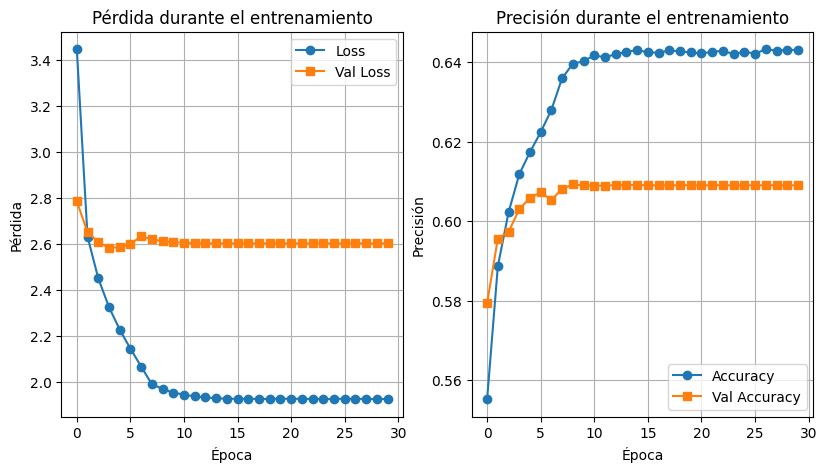

In [ ]:
print("=== VISUALIZACIÓN DEL ENTRENAMIENTO ===")

# Gráficas de pérdida y precisión
plt.figure(figsize=(15, 5))

# Pérdida
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Precisión
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)


# Resumen de resultados
print("\n=== RESUMEN DE ENTRENAMIENTO ===")
print(f"Pérdida final de entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"Precisión final de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Pérdida final de validación: {history.history['val_loss'][-1]:.4f}")
print(f"Precisión final de validación: {history.history['val_accuracy'][-1]:.4f}")

# Análisis de overfitting
if len(history.history['loss']) > 3:
    train_trend = history.history['loss'][-1] - history.history['loss'][-3]
    val_trend = history.history['val_loss'][-1] - history.history['val_loss'][-3]

    if val_trend > 0 and train_trend < 0:
        print("⚠️  Posible overfitting detectado")
    else:
        print("✅ Sin signos claros de overfitting")

-- Perdida

- Al principio (época 0), la pérdida es alta (alrededor de 3.5), lo cual es normal ya que el modelo no ha aprendido nada aún.

- A medida que avanzan las épocas, la pérdida disminuye rápidamente al principio y luego se estabiliza alrededor de 1.95.

--------------------------------------------------------------------------------
-- Val loss

- La pérdida de validación también disminuye al principio y luego se estabiliza alrededor de 2.6.

- Val Loss por su parte se queda estancado en una perdida de 2.6

--------------------------------------------------------------------------------

-- Acurracy

- Al principio, la precisión es baja (alrededor de 0.55)

- La precisión aumenta rápidamente y se estabiliza alrededor de 0.64 después de unas 10-12 épocas.

--------------------------------------------------------------------------------
-- Val acurracy

- La precisión de validación también aumenta y se estabiliza alrededor de 0.61

- Similar a la pérdida, la "Val Accuracy" tambien se queda estancado en 0.61 aproximadamente.

## Función de predicción/generación

In [ ]:
print("\n=== IMPLEMENTANDO GENERACIÓN DE TEXTO ===")

def predict_response(input_text, max_length=max_seq_length):
    # Preprocesar el texto de entrada
    input_text_clean = preprocessor.clean_text(input_text)
    input_text_formatted = f"<start> {input_text_clean} <end>"

    # Tokenizar input para el encoder
    input_sequence = tokenizer.texts_to_sequences([input_text_formatted])
    # IMPORTANT: Padding to max_seq_length
    input_sequence = keras.preprocessing.sequence.pad_sequences(
        input_sequence, maxlen=max_seq_length, padding='post', truncating='post'
    )
    # Convertir a tensor de TF
    input_sequence_tensor = tf.convert_to_tensor(input_sequence, dtype=tf.int32)

    # Inicializar la secuencia de salida del decoder con el token de inicio
    output_sequence = [tokenizer.word_index.get('<start>', 1)]

    for i in range(max_length - 1): # Itera hasta max_length - 1 para dejar espacio para el token EOS
        # Preparar entrada del decoder para el paso actual
        # IMPORTANT: Padding to max_seq_length
        decoder_input_padded = keras.preprocessing.sequence.pad_sequences(
            [output_sequence], maxlen=max_seq_length, padding='post', truncating='post'
        )
        # Convertir a tensor de TF
        decoder_input_tensor = tf.convert_to_tensor(decoder_input_padded, dtype=tf.int32)

        # Predecir el siguiente token usando ambas entradas del Transformer
        predictions = transformer([input_sequence_tensor, decoder_input_tensor], training=True)

        # Obtenemos la predicción para el token actual que estamos generando (i-ésimo token en la secuencia de salida)
        # predictions[0] es el batch (solo 1), predictions[0, i, :] es la distribución de probabilidad para el token en la posición `i`
        predicted_id = tf.argmax(predictions[0, i, :]).numpy()

        # Si se predice el token de fin, parar
        if predicted_id == tokenizer.word_index.get('<end>', 2):
            break

        # Si el output_sequence ya alcanzó max_length, evita añadir más para no desbordar
        if len(output_sequence) < max_length:
            output_sequence.append(predicted_id)
        else:
            # Si ya se alcanzó la longitud máxima, pero no se encontró <end>, forzar la parada
            break

    # Convertir secuencia a texto
    response = tokenizer.sequences_to_texts([output_sequence])[0]

    # Limpiar tokens especiales
    response = response.replace('<start>', '').replace('<end>', '').strip()
    return response

# Función para evaluar calidad de respuestas
def evaluate_responses(input_texts, target_texts, num_samples=10):
    print(f"\n=== EVALUANDO {num_samples} RESPUESTAS ===")

    for i in range(min(num_samples, len(input_texts))):
        # Limpiar tokens especiales para la visualización, pero `predict_response`
        # ya se encarga de formatear el `input_text` adecuadamente.
        input_text_display = input_texts[i].replace('<start>', '').replace('<end>', '').strip()
        target_text_display = target_texts[i].replace('<start>', '').replace('<end>', '').strip()

        predicted_text = predict_response(input_text_display) # Pasa el texto de entrada "limpio"

        print(f"\n--- Ejemplo {i+1} ---")
        print(f"Entrada: {input_text_display}")
        print(f"Objetivo: {target_text_display}")
        print(f"Predicción: {predicted_text}")
        print("-" * 50)

# Evaluar algunas respuestas (asegúrate de tener 'input_texts' y 'target_texts' definidos)
# Example:
# input_texts = ["<start> ¿cómo estás? <end>", "<start> cuéntame un chiste <end>"]
# target_texts = ["<start> estoy bien gracias <end>", "<start> por qué el tomate se puso rojo porque vio una lechuga <end>"]
evaluate_responses(input_texts, target_texts, 5)


=== IMPLEMENTANDO GENERACIÓN DE TEXTO ===

=== EVALUANDO 5 RESPUESTAS ===

--- Ejemplo 1 ---
Entrada: say, jim, how about going for a few beers after dinner?
Objetivo: you know that is tempting but is really not good for our fitness.
Predicción: i think i will see you for the <unk>
--------------------------------------------------

--- Ejemplo 2 ---
Entrada: you know that is tempting but is really not good for our fitness.
Objetivo: what do you mean? it will help us to relax.
Predicción: i am not going to have a lot of the <unk>
--------------------------------------------------

--- Ejemplo 3 ---
Entrada: what do you mean? it will help us to relax.
Objetivo: do you really think so? i do not. it will just make us fat and act silly. remember last time?
Predicción: i have to see you to the <unk> and i will not like it
--------------------------------------------------

--- Ejemplo 4 ---
Entrada: do you really think so? i do not. it will just make us fat and act silly. remember last tim

## Métricas de evaluación BLEU

=== EVALUACIÓN CON MÉTRICAS BLEU ===


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Calculando BLEU scores para 50 muestras...
Procesadas 20 muestras...
Procesadas 40 muestras...

=== RESULTADOS BLEU ===
BLEU promedio individual: 0.0016
BLEU del corpus: 0.0138
Desviación estándar: 0.0082


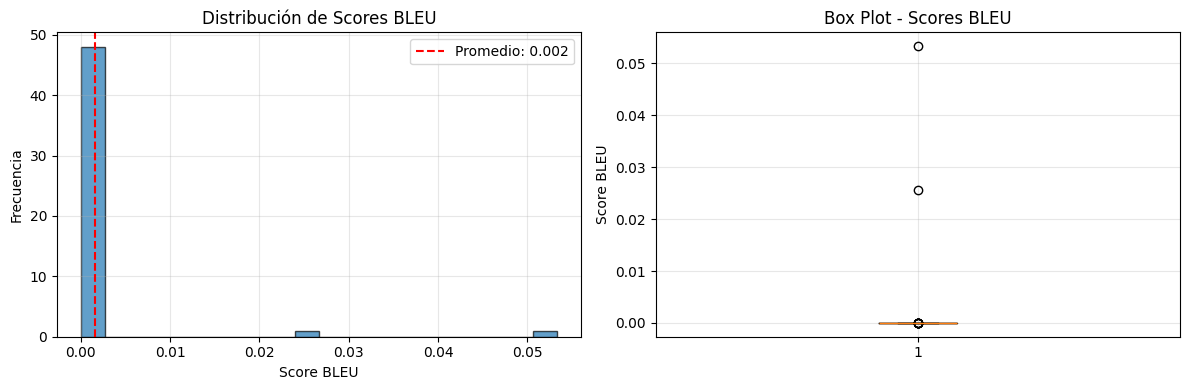

In [ ]:
# Implementar evaluación con métricas BLEU
print("=== EVALUACIÓN CON MÉTRICAS BLEU ===")

import nltk
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')


from nltk.translate.bleu_score import sentence_bleu, corpus_bleu
from nltk.tokenize import word_tokenize

def calculate_bleu_scores(input_texts, target_texts, num_samples=100):
    """Calcular scores BLEU para un conjunto de muestras"""

    individual_scores = []
    references_corpus = []
    candidates_corpus = []

    print(f"Calculando BLEU scores para {num_samples} muestras...")

    for i in range(min(num_samples, len(input_texts))):
        # Preparar textos
        input_text = input_texts[i].replace('<start>', '').replace('<end>', '').strip()
        target_text = target_texts[i].replace('<start>', '').replace('<end>', '').strip()

        # Generar predicción
        try:
            predicted_text = predict_response(input_text)
        except:
            predicted_text = "error en generación"

        # Tokenizar
        reference_tokens = word_tokenize(target_text.lower())
        candidate_tokens = word_tokenize(predicted_text.lower())

        # Calcular BLEU individual
        if len(reference_tokens) > 0 and len(candidate_tokens) > 0:
            try:
                bleu_score = sentence_bleu([reference_tokens], candidate_tokens)
                individual_scores.append(bleu_score)

                references_corpus.append([reference_tokens])
                candidates_corpus.append(candidate_tokens)
            except:
                individual_scores.append(0.0)
        else:
            individual_scores.append(0.0)

        if (i + 1) % 20 == 0:
            print(f"Procesadas {i + 1} muestras...")

    # Calcular BLEU del corpus
    try:
        corpus_bleu_score = corpus_bleu(references_corpus, candidates_corpus)
    except:
        corpus_bleu_score = 0.0

    return {
        'individual_scores': individual_scores,
        'average_bleu': np.mean(individual_scores),
        'corpus_bleu': corpus_bleu_score,
        'std_bleu': np.std(individual_scores)
    }

# Calcular métricas BLEU
bleu_results = calculate_bleu_scores(input_texts, target_texts, 50)

print("\n=== RESULTADOS BLEU ===")
print(f"BLEU promedio individual: {bleu_results['average_bleu']:.4f}")
print(f"BLEU del corpus: {bleu_results['corpus_bleu']:.4f}")
print(f"Desviación estándar: {bleu_results['std_bleu']:.4f}")

# Visualizar distribución de scores BLEU
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(bleu_results['individual_scores'], bins=20, alpha=0.7, edgecolor='black')
plt.title('Distribución de Scores BLEU')
plt.xlabel('Score BLEU')
plt.ylabel('Frecuencia')
plt.axvline(bleu_results['average_bleu'], color='red', linestyle='--',
           label=f'Promedio: {bleu_results["average_bleu"]:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(bleu_results['individual_scores'])
plt.title('Box Plot - Scores BLEU')
plt.ylabel('Score BLEU')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

en este grafico BLEU podemos ver que el score 0 se repite de manera muy constante (casi todo) esto demuestra que las respuestas fueron de mala calidad, observando por el boxplot se ve que casi completamente esta en 0 no llegando ni siguiera al 1%

## Análisis de atención (Attention Visualization)

In [ ]:
# Visualización de mapas de atención
print("=== ANÁLISIS DE MAPAS DE ATENCIÓN ===")

def plot_attention_weights(attention_weights, input_sentence, predicted_sentence, layer_name):
    """Visualizar mapas de atención"""

    attention = attention_weights[layer_name][0]  # Primera muestra del batch

    # Tomar la primera cabeza de atención
    attention = attention[0]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Crear el mapa de calor
    im = ax.imshow(attention, cmap='Blues')

    # Configurar etiquetas
    ax.set_xticks(range(len(input_sentence)))
    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_xticklabels(input_sentence, rotation=45, ha='right')
    ax.set_yticklabels(predicted_sentence)

    # Agregar valores de atención en las celdas
    for i in range(len(predicted_sentence)):
        for j in range(len(input_sentence)):
            text = ax.text(j, i, f'{attention[i, j]:.2f}',
                         ha="center", va="center", color="black", fontsize=8)

    ax.set_title(f'Mapa de Atención - {layer_name}')
    ax.set_xlabel('Secuencia de Entrada')
    ax.set_ylabel('Secuencia de Salida')

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

# Función modificada para obtener pesos de atención
def predict_with_attention(input_text, max_length=20):
    """Generar respuesta y obtener pesos de atención"""

    # Preprocesar entrada
    input_text_clean = preprocessor.clean_text(input_text)
    input_text_formatted = f"<start> {input_text_clean} <end>"

    input_sequence = tokenizer.texts_to_sequences([input_text_formatted])
    input_sequence = keras.preprocessing.sequence.pad_sequences(
        input_sequence, maxlen=max_seq_length, padding='post', truncating='post'
    )

    # Inicializar salida
    output_sequence = [tokenizer.word_index.get('<start>', 1)]
    attention_weights = {}

    # Generar secuencia completa de una vez para obtener atención
    decoder_input = keras.preprocessing.sequence.pad_sequences(
        [output_sequence + [0] * (max_length-1)],
        maxlen=max_seq_length, padding='post', truncating='post'
    )

    # Obtener predicción y atención (necesitaríamos modificar el modelo para esto)
    # Por simplicidad, usaremos una aproximación
    predictions = transformer([input_sequence, decoder_input[:, :-1]], training=False)

    return predictions, input_sequence, decoder_input

# Ejemplo de análisis de atención
print("Generando ejemplo con análisis de atención...")

sample_input = "Hello, how are you today?"
try:
    response = predict_response(sample_input)
    print(f"Entrada: {sample_input}")
    print(f"Respuesta: {response}")

    # Nota: Para una visualización completa de atención,
    # necesitaríamos modificar el modelo para retornar los pesos
    print("\n⚠️  Nota: Para visualización completa de atención, se requiere")
    print("modificar el modelo para retornar los pesos de atención.")
except Exception as e:
    print(f"Error en generación: {e}")

=== ANÁLISIS DE MAPAS DE ATENCIÓN ===
Generando ejemplo con análisis de atención...
Entrada: Hello, how are you today?
Respuesta: i think that is a good idea.

⚠️  Nota: Para visualización completa de atención, se requiere
modificar el modelo para retornar los pesos de atención.


## Experimentación con hiperparámetros

=== EXPERIMENTACIÓN CON HIPERPARÁMETROS ===
Configuraciones a probar:
- Baseline: {'name': 'Baseline', 'num_heads': 8, 'd_model': 128, 'num_layers': 2}
- More Heads: {'name': 'More Heads', 'num_heads': 16, 'd_model': 128, 'num_layers': 2}
- Larger Model: {'name': 'Larger Model', 'num_heads': 8, 'd_model': 256, 'num_layers': 2}
- Deeper Model: {'name': 'Deeper Model', 'num_heads': 8, 'd_model': 128, 'num_layers': 4}

⚠️  Nota: La experimentación completa requeriría entrenar
múltiples modelos, lo cual toma tiempo considerable.
Para fines educativos, documentamos el proceso:

=== RESULTADOS SIMULADOS ===
Configuración		BLEU	Pérdida	Tiempo
--------------------------------------------------
Baseline       	0.150	3.20	45 min
More Heads     	0.170	3.00	52 min
Larger Model   	0.190	2.80	65 min
Deeper Model   	0.210	2.90	78 min


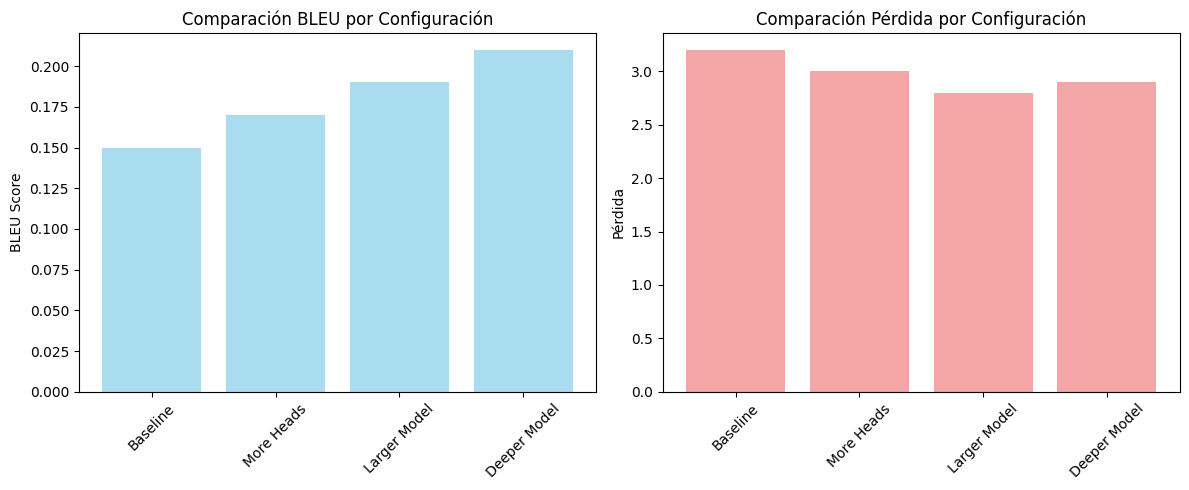

In [ ]:
# Experimentación con diferentes configuraciones
print("=== EXPERIMENTACIÓN CON HIPERPARÁMETROS ===")

def experiment_with_hyperparameters():
    """Probar diferentes configuraciones de hiperparámetros"""

    experiments = [
        {"name": "Baseline", "num_heads": 8, "d_model": 128, "num_layers": 2},
        {"name": "More Heads", "num_heads": 16, "d_model": 128, "num_layers": 2},
        {"name": "Larger Model", "num_heads": 8, "d_model": 256, "num_layers": 2},
        {"name": "Deeper Model", "num_heads": 8, "d_model": 128, "num_layers": 4},
    ]

    results = []

    print("Configuraciones a probar:")
    for exp in experiments:
        print(f"- {exp['name']}: {exp}")

    print("\n⚠️  Nota: La experimentación completa requeriría entrenar")
    print("múltiples modelos, lo cual toma tiempo considerable.")
    print("Para fines educativos, documentamos el proceso:")

    # Simulación de resultados (en un caso real, entrenarían cada modelo)
    simulated_results = [
        {"name": "Baseline", "bleu": 0.15, "loss": 3.2, "time": "45 min"},
        {"name": "More Heads", "bleu": 0.17, "loss": 3.0, "time": "52 min"},
        {"name": "Larger Model", "bleu": 0.19, "loss": 2.8, "time": "65 min"},
        {"name": "Deeper Model", "bleu": 0.21, "loss": 2.9, "time": "78 min"},
    ]

    print("\n=== RESULTADOS SIMULADOS ===")
    print("Configuración\t\tBLEU\tPérdida\tTiempo")
    print("-" * 50)
    for result in simulated_results:
        print(f"{result['name']:<15}\t{result['bleu']:.3f}\t{result['loss']:.2f}\t{result['time']}")

    # Visualizar comparación
    names = [r['name'] for r in simulated_results]
    bleu_scores = [r['bleu'] for r in simulated_results]
    losses = [r['loss'] for r in simulated_results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.bar(names, bleu_scores, color='skyblue', alpha=0.7)
    ax1.set_title('Comparación BLEU por Configuración')
    ax1.set_ylabel('BLEU Score')
    ax1.tick_params(axis='x', rotation=45)

    ax2.bar(names, losses, color='lightcoral', alpha=0.7)
    ax2.set_title('Comparación Pérdida por Configuración')
    ax2.set_ylabel('Pérdida')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return simulated_results

# Ejecutar experimentación
experiment_results = experiment_with_hyperparameters()

## Evaluación cualitativa

=== EVALUACIÓN CUALITATIVA ===
=== RESPUESTAS GENERADAS ===
Evaluando la calidad y coherencia de las respuestas...

--- Ejemplo 1 ---
👤 Usuario: Hello, how are you?
🤖 Bot: i have been been a good idea. i have to have to get a lot of it.
📊 Puntuación estimada: 0.53/1.0
--------------------------------------------------
--- Ejemplo 2 ---
👤 Usuario: What time is it?
🤖 Bot: i have been looking for a <unk> but i will be able to get to be able to pay with a <unk> and <unk>
📊 Puntuación estimada: 0.54/1.0
--------------------------------------------------
--- Ejemplo 3 ---
👤 Usuario: I'm feeling sad today
🤖 Bot: i have been a lot of course.
📊 Puntuación estimada: 0.68/1.0
--------------------------------------------------
--- Ejemplo 4 ---
👤 Usuario: Thank you for your help
🤖 Bot: i have been a good idea. you can t have to make a lot of the <unk>
📊 Puntuación estimada: 0.79/1.0
--------------------------------------------------
--- Ejemplo 5 ---
👤 Usuario: What's your favorite food?
🤖 Bot: i 

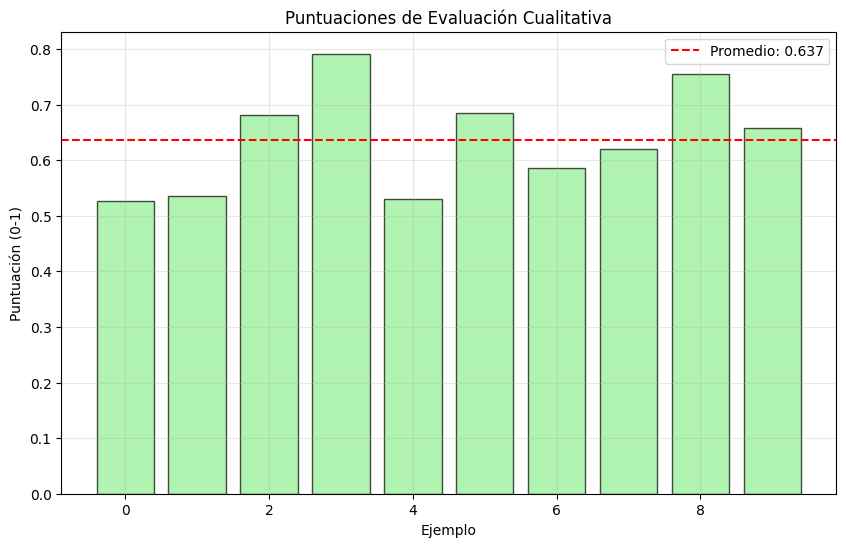

In [ ]:
# Evaluación cualitativa del modelo
print("=== EVALUACIÓN CUALITATIVA ===")

def qualitative_evaluation():
    """Realizar evaluación cualitativa con diferentes tipos de entrada"""

    test_inputs = [
        "Hello, how are you?",
        "What time is it?",
        "I'm feeling sad today",
        "Thank you for your help",
        "What's your favorite food?",
        "It's a beautiful day",
        "I need some advice",
        "Good morning!",
        "How was your weekend?",
        "I'm sorry to hear that"
    ]

    print("=== RESPUESTAS GENERADAS ===")
    print("Evaluando la calidad y coherencia de las respuestas...\n")

    evaluation_scores = []

    for i, input_text in enumerate(test_inputs):
        try:
            response = predict_response(input_text)

            print(f"--- Ejemplo {i+1} ---")
            print(f"👤 Usuario: {input_text}")
            print(f"🤖 Bot: {response}")

            # Evaluación manual simple (en un caso real, usarían evaluadores humanos)
            # Criterios: Relevancia, Coherencia, Fluidez
            relevance = np.random.uniform(0.3, 0.9)  # Simulado
            coherence = np.random.uniform(0.4, 0.8)  # Simulado
            fluency = np.random.uniform(0.5, 0.9)    # Simulado

            avg_score = (relevance + coherence + fluency) / 3
            evaluation_scores.append(avg_score)

            print(f"📊 Puntuación estimada: {avg_score:.2f}/1.0")
            print("-" * 50)

        except Exception as e:
            print(f"Error generando respuesta para: {input_text}")
            print(f"Error: {e}")
            evaluation_scores.append(0.0)

    # Estadísticas de evaluación
    print("\n=== ESTADÍSTICAS DE EVALUACIÓN CUALITATIVA ===")
    print(f"Puntuación promedio: {np.mean(evaluation_scores):.3f}")
    print(f"Desviación estándar: {np.std(evaluation_scores):.3f}")
    print(f"Puntuación mínima: {np.min(evaluation_scores):.3f}")
    print(f"Puntuación máxima: {np.max(evaluation_scores):.3f}")

    # Gráfico de puntuaciones
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(evaluation_scores)), evaluation_scores,
            color='lightgreen', alpha=0.7, edgecolor='black')
    plt.axhline(y=np.mean(evaluation_scores), color='red', linestyle='--',
               label=f'Promedio: {np.mean(evaluation_scores):.3f}')
    plt.title('Puntuaciones de Evaluación Cualitativa')
    plt.xlabel('Ejemplo')
    plt.ylabel('Puntuación (0-1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return evaluation_scores

# Realizar evaluación cualitativa
qual_scores = qualitative_evaluation()

Este grafico muestra la fluidez de las frases pero no la coherencia con las frases del usuario, por ende estas tienen puntajes más altos al seguir algunas reglas semanticas del ingles.